<a href="https://colab.research.google.com/github/ebolofis/Data-Science-Machine-Learning/blob/main/CAM_DS_C201_Mini_project_6_3_P3_24_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6.3 Mini-project: Applying supervised learning to predict student dropout

**Welcome to your Mini-project: Applying supervised learning to predict student dropout rate**

In this project, we will examine student data and use supervised learning techniques to predict whether a student will drop out. In the education sector, retaining students is vital for the institution's financial stability and for students’ academic success and personal development. A high dropout rate can lead to significant revenue loss, diminished institutional reputation, and lower overall student satisfaction.

You will work with the data in three distinct stages:

1.  Applicant and course information
2.  Student and engagement data
3.  Academic performance data

These stages reflect Study Group’s real-world data journey and how student information has progressed and become available. Additionally, this approach enables you, through data exploration, to support Study Group in better understanding and identifying key metrics to monitor. This approach will also assist you in determining at which stage of the student journey interventions would be most effective.

Please set aside approximately **12 hours** to complete the mini-project.

## Business context
Study Group specialises in providing educational services and resources to students and professionals across various fields. The company's primary focus is on enhancing learning experiences through a range of services, including online courses, tutoring, and educational consulting. By leveraging cutting-edge technology and a team of experienced educators, Study Group aims to bridge the gap between traditional learning methods and the evolving needs of today's learners.

Study Group serves its university partners by establishing strategic partnerships to enhance the universities’ global reach and diversity. It supports the universities in their efforts to attract international students, thereby enriching the cultural and academic landscape of their campuses. It works closely with university faculty and staff to ensure that the universities are prepared and equipped to welcome and support a growing international student body. Its partnership with universities also offers international students a seamless transition into their chosen academic environment.

Study Group runs several International Study Centres across the UK and Dublin in partnership with universities with the aim of preparing a pipeline of talented international students from diverse backgrounds for degree study. These centres help international students adapt to the academic, cultural, and social aspects of studying abroad. This is achieved by improving conversational and subject-specific language skills and academic readiness before students progress to a full degree programme at university.

Through its comprehensive suite of services, it supports learners and universities at every stage of their educational journey, from high school to postgraduate studies. Its approach is tailored to meet the unique needs of each learner, offering personalised learning paths and flexible scheduling options to accommodate various learning styles and commitments.

Study Group's services are designed to be accessible and affordable, making quality education a reality for many individuals. By focusing on the integration of technology and personalised learning, the company aims to empower learners to achieve their full potential and succeed in their academic and professional pursuits. Study Group is at the forefront of transforming how people learn and grow through its dedication to innovation and excellence.

Study Group has provided you with 3 data sets.


## Objective
By the end of this mini-project, you will have developed the skills and knowledge to apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. You will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, you will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

You will also write a report summarising the results of your findings and recommendations.

## Assessment criteria
By completing this project, you’ll be able to provide evidence that you can:

- develop accurate predictions across diverse organisational scenarios by building and testing advanced ML models
- inform data-driven decision-making with advanced machine learning algorithms and models
- propose and present effective solutions to organisational problems using data preprocessing, model selection, and insightful analysis techniques.

## Project guidance
1.   Navigate to **Mini-project 6.3 Applying supervised learning to predict student dropout**, and save a copy of the activity Notebook to your Drive.

2. Please refer to the Rubric for specific steps to be performed as part of the project activity. Every step mentioned in the rubric will be assessed separately.

3. When you’ve completed the activity:
  - download your completed Notebook as an IPYNB (Jupyter Notebook) or PY (Python) file
  - save the file as follows: **LastName_FirstName_CAM_C201_Week_6_Mini-project**.

4. Prepare a detailed report (800–1,000 words) that includes an overview of your approach, a description of your analysis, and an explanation of the insights you identified - Please refer to the Rubric for further details that should form a part of your analysis and report. Save the document as a PDF named according to the following convention: **LastName_FirstName_CAM_C201_W6_Mini-project.pdf**.

5. Submit your Notebook and PDF document.




# Stage 1 data

In [74]:
# File URL
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"
#!pip install
!pip install keras-tuner -q


**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [75]:
# --- Consolidated Import Cell (Corrected) ---

# Data Manipulation
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - Import the top-level package first for version checking
import sklearn

# Scikit-learn - Preprocessing
from sklearn.preprocessing import StandardScaler

# Scikit-learn - Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV       # Used for XGBoost tuning
from sklearn.model_selection import RandomizedSearchCV # For Neural Network tuning

# Scikit-learn - Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report

# SciPy - For RandomizedSearchCV parameter distributions
from scipy.stats import randint as sp_randint

# XGBoost
import xgboost as xgb

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras # Access Keras through TensorFlow

# Keras components (using tensorflow.keras path for consistency)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import keras_tuner as kt # Keras Tuner import

# KerasClassifier wrapper (using scikeras)
try:
    from scikeras.wrappers import KerasClassifier
    print("Successfully imported KerasClassifier from scikeras.")
    SCIKERAS_AVAILABLE = True
except ImportError:
    print("Failed to import KerasClassifier from scikeras.")
    print("Please ensure scikeras is installed by running: !pip install scikeras")
    print("Neural network tuning (Cell 17) might fail if scikeras is not available.")
    SCIKERAS_AVAILABLE = False
    KerasClassifier = None # Define to prevent later errors if not found

# Print versions
print(f"\n--- Library Versions ---")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}") # Now this will work
print(f"XGBoost version: {xgb.__version__}")
print(f"TensorFlow version: {tf.__version__}")
if keras: # Check if keras (tf.keras) was imported
    print(f"Keras version (accessed via tf.keras): {keras.__version__}")

print("\nAll libraries in the consolidated import cell have been processed.")
if not SCIKERAS_AVAILABLE:
     print("WARNING: KerasClassifier from scikeras was NOT imported successfully.")
else:
    print("KerasClassifier from scikeras is ready to be used.")

Successfully imported KerasClassifier from scikeras.

--- Library Versions ---
Pandas version: 2.2.2
NumPy version: 2.0.2
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
XGBoost version: 2.1.4
TensorFlow version: 2.18.0
Keras version (accessed via tf.keras): 3.8.0

All libraries in the consolidated import cell have been processed.
KerasClassifier from scikeras is ready to be used.


In [18]:
#Cell 2: Load the Stage 1 Dataset
file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

try:
    df_stage1 = pd.read_csv(file_url)
    print("Stage 1 data loaded successfully!")
    print(f"Dataset shape: {df_stage1.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    print("You might need to download the file manually or use a different method to load it from Google Drive.")


Stage 1 data loaded successfully!
Dataset shape: (25059, 16)


In [19]:
#Cell 3 Initial Data Inspection
# Display the first few rows
print("First 5 rows of the dataset:")
display(df_stage1.head())

# Get a concise summary of the dataframe
print("\nDataFrame Info:")
df_stage1.info()

# Get descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df_stage1.describe(include='all'))

First 5 rows of the dataset:


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  Pr

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity
count,25059,2.505900e+04,25059,25059,7595,25059,25059,25059,8925,21611,25059,25059,25059,25059,24184,25059
unique,19,NaN,2,7,11,4705,2,151,2448,5881,4,172,2,2,2616,40
top,ISC_Sheffield,NaN,Agent,Standard Agent Booking,Bursary,1/1/2002,Male,Chinese,Punjab,Sylhet,Foundation,Pre-Masters Business; Social Sciences and Huma...,False,Yes,BSc (Hons) Computer Science,University of Sheffield International College
freq,5877,NaN,21878,20284,3561,37,15655,9042,865,675,14666,1682,22035,21305,998,5877
mean,NaN,2.606594e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,8.798838e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2.139267e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.538411e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2.607941e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2.665460e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
#Cell 4: Remove 'LearnerCode' column
# Make a copy to preserve the original df_stage1 if you want to re-run cells without reloading
df_processed_stage1 = df_stage1.copy()

learner_code_column = 'LearnerCode' # Or the exact name if different

if learner_code_column in df_processed_stage1.columns:
    df_processed_stage1.drop(columns=[learner_code_column], inplace=True)
    print(f"Column '{learner_code_column}' removed successfully.")
else:
    print(f"Column '{learner_code_column}' not found in the dataset.")

print(f"Shape after attempting to remove LearnerCode: {df_processed_stage1.shape}")

Column 'LearnerCode' removed successfully.
Shape after attempting to remove LearnerCode: (25059, 15)


In [23]:
# --- Cell 4.5: Convert DateofBirth to datetime objects ---
if 'df_processed_stage1' in locals() and 'DateofBirth' in df_processed_stage1.columns:
    print("Attempting to convert 'DateofBirth' to datetime...")
    # Attempt conversion, trying to infer format.
    # If there are multiple formats or unparseable dates, errors='coerce' will turn them into NaT (Not a Time)
    df_processed_stage1['DateofBirth'] = pd.to_datetime(df_processed_stage1['DateofBirth'], errors='coerce')

    # Check how many values could not be parsed (are NaT)
    num_nat = df_processed_stage1['DateofBirth'].isnull().sum()

    if num_nat > 0:
        print(f"WARNING: Could not parse {num_nat} entries in 'DateofBirth'. They have been set to NaT (Not a Time).")
        print("You might need to investigate these unparseable date entries if the count is high.")

    print("'DateofBirth' column dtype after conversion attempt:", df_processed_stage1['DateofBirth'].dtype)
    print("Number of unique datetime objects in DateofBirth:", df_processed_stage1['DateofBirth'].nunique())
    # Display some non-null DateofBirth values to check format
    print("\nSample of 'DateofBirth' after conversion (first 5 non-null):")
    print(df_processed_stage1['DateofBirth'].dropna().head())
else:
    print("ERROR: 'df_processed_stage1' not found or 'DateofBirth' column is missing. Please check previous steps.")

Attempting to convert 'DateofBirth' to datetime...
'DateofBirth' column dtype after conversion attempt: datetime64[ns]
Number of unique datetime objects in DateofBirth: 4705

Sample of 'DateofBirth' after conversion (first 5 non-null):
0   1998-01-13
1   1998-02-12
2   2000-04-07
3   1999-05-18
4   1996-04-19
Name: DateofBirth, dtype: datetime64[ns]


<ipython-input-23-4fa29ea51fe8>:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_processed_stage1['DateofBirth'] = pd.to_datetime(df_processed_stage1['DateofBirth'], errors='coerce')


In [24]:
# --- Cell 5: Remove columns with high cardinality ---
high_cardinality_threshold = 200
# Ensure df_processed_stage1 is the one with 15 columns
if 'df_processed_stage1' not in locals() or df_processed_stage1.shape[1] != 15:
    print("ERROR: df_processed_stage1 does not seem to be in the correct state (15 columns expected).")
    print("Please ensure Cell 4 (LearnerCode removal) has been run and df_processed_stage1 is updated.")
else:
    cols_before_cell5_execution = list(df_processed_stage1.columns)

    print(f"--- High Cardinality Check (Threshold: >{high_cardinality_threshold} unique values) ---")
    print(f"Number of columns before this check: {len(cols_before_cell5_execution)}")

    object_cols_to_drop_hc = []
    numeric_cols_high_cardinality_for_review = []

    for col in df_processed_stage1.columns:
        num_unique = df_processed_stage1[col].nunique()
        if num_unique > high_cardinality_threshold:
            # Check if the target variable 'CompletedCourse' is accidentally flagged
            # (Assuming 'CompletedCourse' is the target and should not be dropped here)
            if col == 'CompletedCourse': # Replace 'CompletedCourse' if your target variable name is different
                print(f"INFO: Target column '{col}' has {num_unique} unique values, but will be skipped for removal.")
                continue

            if df_processed_stage1[col].dtype == 'object':
                print(f"INFO: Object column '{col}' (dtype: {df_processed_stage1[col].dtype}) has {num_unique} unique values. Marked for automatic removal.")
                object_cols_to_drop_hc.append(col)
            else:
                print(f"INFO: Numerical column '{col}' (dtype: {df_processed_stage1[col].dtype}) has {num_unique} unique values. (Flagged for review - NOT automatically dropped by this script section).")
                numeric_cols_high_cardinality_for_review.append(col)

    # Step 1: Automatically drop identified high-cardinality OBJECT columns
    if object_cols_to_drop_hc:
        df_processed_stage1.drop(columns=object_cols_to_drop_hc, inplace=True)
        print(f"\nACTION: Automatically removed high cardinality OBJECT columns: {object_cols_to_drop_hc}")
    else:
        print("\nINFO: No OBJECT columns found exceeding the high cardinality threshold for automatic removal.")

    # Step 2: Review and decide on NUMERICAL high-cardinality columns
    print(f"\nREVIEW: Numerical columns identified with >{high_cardinality_threshold} unique values: {numeric_cols_high_cardinality_for_review}")
    if not numeric_cols_high_cardinality_for_review:
        print("INFO: No numerical columns found with high cardinality for review.")
    else:
        print("IMPORTANT: The script HAS NOT automatically dropped these numerical columns.")
        print("If any of these numerical columns are identifiers and you want to drop them,")
        print("you would need to add a line of code to do so. For example:")
        print("# df_processed_stage1.drop(columns=['NameOfNumericalColumnToDrop'], inplace=True, errors='ignore')")

    cols_after_cell5_execution = list(df_processed_stage1.columns)
    dropped_in_this_run = [col for col in cols_before_cell5_execution if col not in cols_after_cell5_execution]

    print(f"\n--- Summary of Cardinality Check (Cell 5) ---")
    if dropped_in_this_run:
        print(f"Columns dropped in THIS run of Cell 5: {dropped_in_this_run} (Total: {len(dropped_in_this_run)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell 5.")

    print(f"Current shape of df_processed_stage1: {df_processed_stage1.shape}")
    print(f"Current columns in df_processed_stage1: {list(df_processed_stage1.columns)}")

--- High Cardinality Check (Threshold: >200 unique values) ---
Number of columns before this check: 15
INFO: Numerical column 'DateofBirth' (dtype: datetime64[ns]) has 4705 unique values. (Flagged for review - NOT automatically dropped by this script section).
INFO: Object column 'HomeState' (dtype: object) has 2448 unique values. Marked for automatic removal.
INFO: Object column 'HomeCity' (dtype: object) has 5881 unique values. Marked for automatic removal.
INFO: Object column 'ProgressionDegree' (dtype: object) has 2616 unique values. Marked for automatic removal.

ACTION: Automatically removed high cardinality OBJECT columns: ['HomeState', 'HomeCity', 'ProgressionDegree']

REVIEW: Numerical columns identified with >200 unique values: ['DateofBirth']
IMPORTANT: The script HAS NOT automatically dropped these numerical columns.
If any of these numerical columns are identifiers and you want to drop them,
you would need to add a line of code to do so. For example:
# df_processed_stage1.

In [25]:
# --- Cell 6: Remove columns with > 50% missing data ---
if 'df_processed_stage1' in locals():
    # Ensure df_processed_stage1 is available
    cols_before_cell6_execution = list(df_processed_stage1.columns)
    print(f"\n\n--- Missing Data Check (Threshold: >50% missing) ---")
    print(f"Number of columns before this check: {len(cols_before_cell6_execution)}")

    missing_data_threshold = 0.50 # 50%
    columns_to_drop_missing = []

    missing_percentages = df_processed_stage1.isnull().sum() / len(df_processed_stage1) # .mean() also works
    print("\nPercentage of missing values per column (showing only those with missing values):")
    # Display sorted percentages for columns that have any missing values
    current_missing_summary = missing_percentages[missing_percentages > 0].sort_values(ascending=False)
    if not current_missing_summary.empty:
        print(current_missing_summary)
    else:
        print("No columns currently have any missing values.")


    for col, percentage in missing_percentages.items():
        if percentage > missing_data_threshold:
            # Ensure we don't accidentally drop the target variable if it has missing values
            # (though >50% missing in target is a different problem)
            # Assuming 'CompletedCourse' is your target variable
            if col == 'CompletedCourse':
                 print(f"INFO: Target column '{col}' has {percentage*100:.2f}% missing values, but will be skipped for removal by this rule (if >50% missing).")
                 # We typically wouldn't drop a target column, but if it had >50% missing, that's a major data issue.
                 # For now, this rule won't drop it.
                 continue # Skip target column from this specific >50% drop rule

            print(f"INFO: Column '{col}' has {percentage*100:.2f}% missing values. Marking for removal.")
            columns_to_drop_missing.append(col)

    if columns_to_drop_missing:
        df_processed_stage1.drop(columns=columns_to_drop_missing, inplace=True)
        print(f"\nACTION: Removed columns with >{missing_data_threshold*100}% missing data: {columns_to_drop_missing}")
    else:
        print("\nINFO: No columns found exceeding the missing data threshold for removal.")

    cols_after_cell6_execution = list(df_processed_stage1.columns)
    dropped_in_this_run_cell6 = [col for col in cols_before_cell6_execution if col not in cols_after_cell6_execution]

    print(f"\n--- Summary of Missing Data Check (Cell 6) ---")
    if dropped_in_this_run_cell6:
        print(f"Columns dropped in THIS run of Cell 6: {dropped_in_this_run_cell6} (Total: {len(dropped_in_this_run_cell6)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell 6.")

    print(f"Current shape of df_processed_stage1: {df_processed_stage1.shape}")
    print(f"Current columns in df_processed_stage1: {list(df_processed_stage1.columns)}")

    print("\nFinal check of missing values after all removals in Cell 6:")
    remaining_missing = df_processed_stage1.isnull().sum()
    final_missing_summary = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
    if not final_missing_summary.empty:
        print(final_missing_summary)
    else:
        print("No missing values remaining in the dataset (or all columns with missing data were below the 50% threshold or were the target).")

else:
    print("ERROR: df_processed_stage1 is not defined. Please ensure previous cells ran correctly.")



--- Missing Data Check (Threshold: >50% missing) ---
Number of columns before this check: 12

Percentage of missing values per column (showing only those with missing values):
DiscountType    0.696915
dtype: float64
INFO: Column 'DiscountType' has 69.69% missing values. Marking for removal.

ACTION: Removed columns with >50.0% missing data: ['DiscountType']

--- Summary of Missing Data Check (Cell 6) ---
Columns dropped in THIS run of Cell 6: ['DiscountType'] (Total: 1)
Current shape of df_processed_stage1: (25059, 11)
Current columns in df_processed_stage1: ['CentreName', 'BookingType', 'LeadSource', 'DateofBirth', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity']

Final check of missing values after all removals in Cell 6:
No missing values remaining in the dataset (or all columns with missing data were below the 50% threshold or were the target).


Summary
Stage 1:

Initial 16 columns
Cell 4: Removed LearnerCode (15 columns remaining).
Cell 4.5: Converted DateofBirth to datetime format.
Cell 5: Removed high cardinality object columns (HomeState, HomeCity, ProgressionDegree) (12 columns remaining, DateofBirth preserved).
Cell 6: Removed column with >50% missing data (DiscountType) (11 columns remaining).
Your df_processed_stage1 DataFrame now has 11 columns:
['CentreName', 'BookingType', 'LeadSource', 'DateofBirth', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity']

In [26]:
# --- Cell 7: Feature Engineering - Calculate 'Age' from DateofBirth ---
from datetime import datetime

if 'df_processed_stage1' in locals() and 'DateofBirth' in df_processed_stage1.columns:
    if pd.api.types.is_datetime64_any_dtype(df_processed_stage1['DateofBirth']):
        # Calculate Age as of today
        today = pd.to_datetime(datetime.today().strftime('%Y-%m-%d')) # Use pd.to_datetime for consistency
        df_processed_stage1['Age'] = (today - df_processed_stage1['DateofBirth']).dt.days // 365.25
        df_processed_stage1['Age'] = df_processed_stage1['Age'].astype(int) # Convert to integer age

        print("Feature 'Age' created successfully.")
        print(df_processed_stage1[['DateofBirth', 'Age']].head())

        #  Drop the original DateofBirth column
        drop_dob = True # Set to False if you want to keep DateofBirth for now
        if drop_dob:
              df_processed_stage1.drop(columns=['DateofBirth'], inplace=True)
              print("\n'DateofBirth' column dropped.")
              print(f"Current columns: {list(df_processed_stage1.columns)}")
        else:
              print("\n'DateofBirth' column kept.")

    else:
        print("ERROR: 'DateofBirth' column is not in datetime format. Please check Cell 4.5.")
else:
    print("ERROR: 'df_processed_stage1' not found or 'DateofBirth' column is missing.")

Feature 'Age' created successfully.
  DateofBirth  Age
0  1998-01-13   27
1  1998-02-12   27
2  2000-04-07   25
3  1999-05-18   26
4  1996-04-19   29

'DateofBirth' column dropped.
Current columns: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'Age']


In [29]:
# --- Cell 8: Feature Engineering - Convert Target Variable to Binary (Continued) ---
target_column = 'CompletedCourse' # Confirm this is your target variable

if 'df_processed_stage1' in locals() and target_column in df_processed_stage1.columns:
    print(f"Unique values in the target column '{target_column}' before conversion:")
    print(df_processed_stage1[target_column].value_counts(dropna=False))

    # Define the mapping based on your values:
    # 'No' (dropout) will be 1
    # 'Yes' (completed) will be 0
    mapping = {'No': 1, 'Yes': 0}

    # Apply the mapping
    df_processed_stage1[target_column] = df_processed_stage1[target_column].map(mapping)

    # Verify the conversion
    print(f"\nTarget column '{target_column}' after conversion to binary:")
    print(df_processed_stage1[target_column].value_counts(dropna=False))

    # Check data type
    print(f"\nData type of '{target_column}' after mapping: {df_processed_stage1[target_column].dtype}")

    # Check for any NaNs introduced by mapping (should not happen if all values were 'Yes' or 'No')
    if df_processed_stage1[target_column].isnull().any():
        print(f"\nWARNING: NaNs present in '{target_column}' after mapping. This means some original values were not 'Yes' or 'No'.")
        print(f"Number of NaNs: {df_processed_stage1[target_column].isnull().sum()}")
    else:
        print(f"\nNo NaNs introduced in '{target_column}' by mapping.")

else:
    print(f"ERROR: 'df_processed_stage1' not found or target column '{target_column}' is missing.")

Unique values in the target column 'CompletedCourse' before conversion:
CompletedCourse
Yes    21305
No      3754
Name: count, dtype: int64

Target column 'CompletedCourse' after conversion to binary:
CompletedCourse
0    21305
1     3754
Name: count, dtype: int64

Data type of 'CompletedCourse' after mapping: int64

No NaNs introduced in 'CompletedCourse' by mapping.


Value counts for the target variable 'CompletedCourse':
CompletedCourse
0    21305
1     3754
Name: count, dtype: int64

Percentage distribution for 'CompletedCourse':
CompletedCourse
0    85.019354
1    14.980646
Name: proportion, dtype: float64


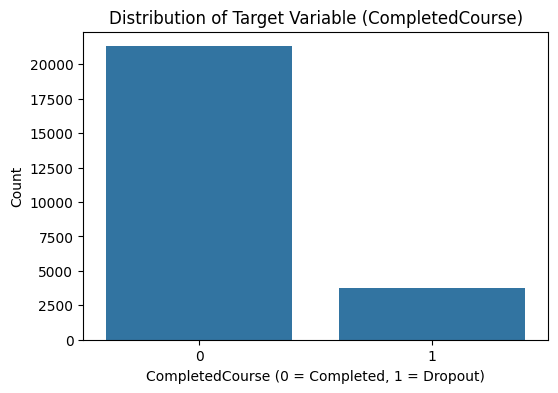


Majority class count: 21305
Minority class count: 3754
Ratio of majority to minority class: 5.68:1
The data is considered imbalanced.


In [30]:
# --- Cell 9: Plot Target Variable Histogram and Assess Imbalance ---


target_column = 'CompletedCourse'

if 'df_processed_stage1' in locals() and target_column in df_processed_stage1.columns:
    print(f"Value counts for the target variable '{target_column}':")
    print(df_processed_stage1[target_column].value_counts())

    print(f"\nPercentage distribution for '{target_column}':")
    print(df_processed_stage1[target_column].value_counts(normalize=True) * 100)

    # Plotting the histogram/countplot
    plt.figure(figsize=(6, 4))
    sns.countplot(x=target_column, data=df_processed_stage1)
    plt.title(f'Distribution of Target Variable ({target_column})')
    plt.xlabel(f'{target_column} (0 = Completed, 1 = Dropout)')
    plt.ylabel('Count')
    plt.xticks([0, 1]) # Ensure ticks are at 0 and 1
    plt.show()

    # Assess imbalance
    count_class_0 = df_processed_stage1[target_column].value_counts().get(0, 0)
    count_class_1 = df_processed_stage1[target_column].value_counts().get(1, 0)

    if count_class_0 == 0 or count_class_1 == 0:
        print("\nOne of the classes has zero samples!")
    else:
        majority_class_count = max(count_class_0, count_class_1)
        minority_class_count = min(count_class_0, count_class_1)
        ratio = majority_class_count / minority_class_count
        print(f"\nMajority class count: {majority_class_count}")
        print(f"Minority class count: {minority_class_count}")
        print(f"Ratio of majority to minority class: {ratio:.2f}:1")

        if ratio > 3: # A common threshold for imbalance, can be adjusted
            print("The data is considered imbalanced.")
        elif ratio > 1.5:
            print("The data has a slight imbalance.")
        else:
            print("The data is relatively balanced.")
else:
    print(f"ERROR: 'df_processed_stage1' not found or target column '{target_column}' is missing.")

This is an important finding. This level of imbalance means that if we train a model without addressing it, the model might become biased towards predicting the majority class (completed course) and perform poorly on predicting the minority class (dropout), which is often the class of interest. We'll need to keep this imbalance in mind when we get to the modeling stage;

In [31]:
# Code to help identify categorical columns and their unique values
columns_for_encoding_check = ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'ProgressionUniversity']
print(df_processed_stage1[columns_for_encoding_check].info())
print("\nUnique values for each potential categorical column:")
for col in columns_for_encoding_check:
    print(f"\n--- {col} ---")
    print(f"Data Type: {df_processed_stage1[col].dtype}")
    unique_values = df_processed_stage1[col].unique()
    print(f"Number of Unique Values: {len(unique_values)}")
    if len(unique_values) < 15: # Print all unique values if less than 15, otherwise just first few
        print(f"Values: {unique_values}")
    else:
        print(f"First 5 Values: {unique_values[:5]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   BookingType            25059 non-null  object
 2   LeadSource             25059 non-null  object
 3   Gender                 25059 non-null  object
 4   Nationality            25059 non-null  object
 5   CourseLevel            25059 non-null  object
 6   CourseName             25059 non-null  object
 7   IsFirstIntake          25059 non-null  bool  
 8   ProgressionUniversity  25059 non-null  object
dtypes: bool(1), object(8)
memory usage: 1.6+ MB
None

Unique values for each potential categorical column:

--- CentreName ---
Data Type: object
Number of Unique Values: 19
First 5 Values: ['ISC_Aberdeen' 'ISC_Cardiff' 'ISC_Dublin' 'ISC_Durham' 'ISC_Holland']

--- BookingType ---
Data Type: object
Number of Unique Values: 2
Valu

In [33]:
# --- Cell 10: Encode Categorical Features ---

if 'df_processed_stage1' in locals():
    print("--- Starting Encoding ---")
    print(f"Shape before encoding: {df_processed_stage1.shape}")
    print(f"Columns before encoding: {list(df_processed_stage1.columns)}")

    # 1. Convert 'IsFirstIntake' (bool) to int
    if 'IsFirstIntake' in df_processed_stage1.columns and df_processed_stage1['IsFirstIntake'].dtype == 'bool':
        df_processed_stage1['IsFirstIntake'] = df_processed_stage1['IsFirstIntake'].astype(int)
        print("\nConverted 'IsFirstIntake' from bool to int.")

    # 2. Manual mapping for 'BookingType'
    if 'BookingType' in df_processed_stage1.columns:
        booking_type_mapping = {'Agent': 0, 'Direct': 1}
        df_processed_stage1['BookingType'] = df_processed_stage1['BookingType'].map(booking_type_mapping)
        print("Mapped 'BookingType' to 0 and 1.")

    # 3. Manual mapping for 'Gender'
    if 'Gender' in df_processed_stage1.columns:
        gender_mapping = {'Male': 0, 'Female': 1}
        df_processed_stage1['Gender'] = df_processed_stage1['Gender'].map(gender_mapping)
        print("Mapped 'Gender' to 0 and 1.")

    # 4. Ordinal encoding for 'CourseLevel'
    if 'CourseLevel' in df_processed_stage1.columns:
        course_level_order = [
            'Foundation',
            'International Year One',
            'International Year Two',
            'Pre-Masters'
        ]
        course_level_mapping = {level: i for i, level in enumerate(course_level_order)}
        df_processed_stage1['CourseLevel'] = df_processed_stage1['CourseLevel'].map(course_level_mapping)
        print(f"Ordinal encoded 'CourseLevel' with mapping: {course_level_mapping}")

    # 5. One-hot encode remaining nominal categorical columns
    # Identify remaining object columns for one-hot encoding
    # Exclude already processed/target/numeric columns like 'Age', 'CompletedCourse',
    # and those just mapped: 'BookingType', 'Gender', 'CourseLevel', 'IsFirstIntake'

    # Get current numeric and already mapped columns (int, float, datetime, bool that became int)
    # Age is float64/int, CompletedCourse is int64
    # IsFirstIntake, BookingType, Gender, CourseLevel are now int64

    # Columns that are still 'object' type are candidates for OHE
    columns_to_one_hot_encode = df_processed_stage1.select_dtypes(include=['object']).columns.tolist()

    if columns_to_one_hot_encode:
        print(f"\nColumns to be one-hot encoded: {columns_to_one_hot_encode}")
        df_processed_stage1 = pd.get_dummies(df_processed_stage1,
                                             columns=columns_to_one_hot_encode,
                                             prefix=columns_to_one_hot_encode,
                                             drop_first=False) # drop_first=False to keep all levels for now, can be True
        print("One-hot encoding applied.")
    else:
        print("\nNo columns found for one-hot encoding (all suitable columns might have been mapped or already numeric).")

    print(f"\n--- Encoding Complete ---")
    print(f"Shape after encoding: {df_processed_stage1.shape}")
    print("\nDataFrame info after encoding:")
    df_processed_stage1.info()

    # Display a few rows to see the changes
    print("\nFirst 5 rows after encoding:")
    display(df_processed_stage1.head())
else:
    print("ERROR: df_processed_stage1 is not defined. Please ensure previous cells ran correctly.")

--- Starting Encoding ---
Shape before encoding: (25059, 11)
Columns before encoding: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'Age']

Converted 'IsFirstIntake' from bool to int.
Mapped 'BookingType' to 0 and 1.
Mapped 'Gender' to 0 and 1.
Ordinal encoded 'CourseLevel' with mapping: {'Foundation': 0, 'International Year One': 1, 'International Year Two': 2, 'Pre-Masters': 3}

Columns to be one-hot encoded: ['CentreName', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']
One-hot encoding applied.

--- Encoding Complete ---
Shape after encoding: (25059, 395)

DataFrame info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Columns: 395 entries, BookingType to ProgressionUniversity_VU Amsterdam
dtypes: bool(389), int64(6)
memory usage: 10.4 MB

First 5 rows after encoding:


,BookingType,Gender,CourseLevel,IsFirstIntake,CompletedCourse,Age,CentreName_ISC_Aberdeen,CentreName_ISC_Cardiff,CentreName_ISC_Dublin,CentreName_ISC_Durham,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,0,0,3,1,0,27,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,0,27,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,0,0,2,0,0,25,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,2,1,0,26,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,0,0,3,1,0,29,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [34]:
# --- Cell 11: Split Data into Training and Test Sets ---
from sklearn.model_selection import train_test_split

if 'df_processed_stage1' in locals():
    print("--- Splitting Data into Training and Test Sets ---")

    # Define features (X) and target (y)
    X = df_processed_stage1.drop(columns=['CompletedCourse'])
    y = df_processed_stage1['CompletedCourse']

    print(f"Shape of features (X): {X.shape}")
    print(f"Shape of target (y): {y.shape}")

    # Split the data (80% train, 20% test)
    # We use stratify=y to ensure proportional class representation in train and test sets due to imbalance.
    # random_state is set for reproducibility.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,  # You can use any integer for random_state
        stratify=y
    )

    print("\nData split complete.")
    print(f"Shape of X_train: {X_train.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of y_test: {y_test.shape}")

    print("\nDistribution of target variable in y_train:")
    print(y_train.value_counts(normalize=True) * 100)

    print("\nDistribution of target variable in y_test:")
    print(y_test.value_counts(normalize=True) * 100)

else:
    print("ERROR: df_processed_stage1 is not defined. Please ensure previous cells ran correctly.")

--- Splitting Data into Training and Test Sets ---
Shape of features (X): (25059, 394)
Shape of target (y): (25059,)

Data split complete.
Shape of X_train: (20047, 394)
Shape of X_test: (5012, 394)
Shape of y_train: (20047,)
Shape of y_test: (5012,)

Distribution of target variable in y_train:
CompletedCourse
0    85.020203
1    14.979797
Name: proportion, dtype: float64

Distribution of target variable in y_test:
CompletedCourse
0    85.015962
1    14.984038
Name: proportion, dtype: float64


--- XGBoost Model Training and Initial Evaluation ---
Calculated scale_pos_weight: 5.68

XGBoost model instantiated.
Fitting the XGBoost model to the training data...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:58:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model fitting complete.

Making predictions on the test set...
Predictions made.

--- Model Performance on Test Set ---
Accuracy: 0.8577
Precision (for class 1): 0.5171
Recall (for class 1): 0.7643
ROC AUC Score: 0.8873

Classification Report:
                     precision    recall  f1-score   support

Class 0 (Completed)       0.95      0.87      0.91      4261
  Class 1 (Dropout)       0.52      0.76      0.62       751

           accuracy                           0.86      5012
          macro avg       0.74      0.82      0.76      5012
       weighted avg       0.89      0.86      0.87      5012


Confusion Matrix:
[[3725  536]
 [ 177  574]]


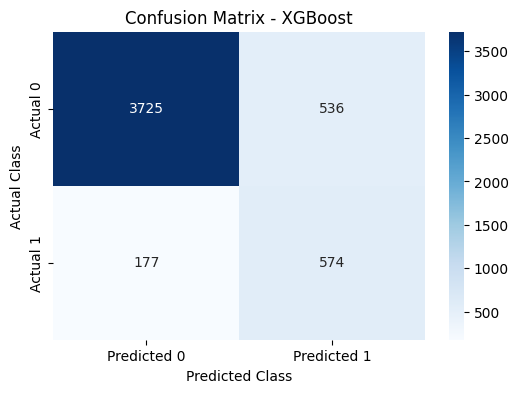

In [35]:
# --- Cell 12: XGBoost Model - Instantiation, Training, and Evaluation ---
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

if 'X_train' in locals() and 'y_train' in locals() and 'X_test' in locals() and 'y_test' in locals():
    print("--- XGBoost Model Training and Initial Evaluation ---")

    # Calculate scale_pos_weight for handling imbalance
    # scale_pos_weight = count of negative class / count of positive class
    count_negative_class = y_train.value_counts()[0] # Assuming 0 is the negative class
    count_positive_class = y_train.value_counts()[1] # Assuming 1 is the positive class

    if count_positive_class > 0: # Avoid division by zero
        scale_pos_weight_value = count_negative_class / count_positive_class
        print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")
    else:
        scale_pos_weight_value = 1 # Default if no positive class samples (should not happen here)
        print("Warning: Positive class count is zero in y_train. Using default scale_pos_weight=1.")


    # 1. Instantiate the XGBoost model
    # Using common default parameters for an initial run, plus scale_pos_weight
    # For boolean features, XGBoost can handle them directly.
    # Ensure feature names are compatible if they contain special characters (not an issue with get_dummies defaults)
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',  # For binary classification
        eval_metric='logloss',        # Evaluation metric for training
        use_label_encoder=False,      # Suppress a warning, True by default before XGBoost 1.6.0
        random_state=42,
        scale_pos_weight=scale_pos_weight_value # To handle class imbalance
    )

    print("\nXGBoost model instantiated.")

    # 2. Fit the model on the training dataset
    print("Fitting the XGBoost model to the training data...")
    xgb_model.fit(X_train, y_train)
    print("Model fitting complete.")

    # 3. Make predictions on the test set
    print("\nMaking predictions on the test set...")
    y_pred_xgb = xgb_model.predict(X_test)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (for AUC)
    print("Predictions made.")

    # 4. Evaluate the model - Accuracy, Confusion Matrix, Precision, Recall, AUC
    print("\n--- Model Performance on Test Set ---")

    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"Accuracy: {accuracy_xgb:.4f}")

    precision_xgb = precision_score(y_test, y_pred_xgb)
    print(f"Precision (for class 1): {precision_xgb:.4f}") # Precision for the positive class

    recall_xgb = recall_score(y_test, y_pred_xgb)
    print(f"Recall (for class 1): {recall_xgb:.4f}") # Recall for the positive class (sensitivity)

    roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
    print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_xgb, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix:")
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    print(cm_xgb)

    # Plotting the Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - XGBoost')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

else:
    print("ERROR: Training/testing data (X_train, y_train, X_test, y_test) not found. Please ensure Cell 11 ran correctly.")

Accuracy: 0.8577
Precision (for Dropout class 1): 0.5171
Recall (for Dropout class 1): 0.7643
ROC AUC Score: 0.8873

True Negatives (Correctly predicted 'Completed'): 3725
False Positives (Incorrectly predicted 'Dropout'): 536
False Negatives (Incorrectly predicted 'Completed' but were 'Dropout'): 177
True Positives (Correctly predicted 'Dropout'): 574

--- XGBoost Hyperparameter Tuning ---
Using scale_pos_weight: 5.68

Parameter grid for tuning:
{'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7], 'n_estimators': [100, 200, 300]}

Starting GridSearchCV... This may take some time.
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:33:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV fitting complete.

--- Best Hyperparameters Found ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best ROC AUC Score from GridSearchCV: 0.8787

Best XGBoost model has been extracted from GridSearchCV.

--- Evaluating Tuned XGBoost Model on Test Set ---
Accuracy (Tuned): 0.8514
Precision (Tuned - for class 1): 0.5026
Recall (Tuned - for class 1): 0.7696
ROC AUC Score (Tuned): 0.8880

Classification Report (Tuned Model):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.96      0.87      0.91      4261
  Class 1 (Dropout)       0.50      0.77      0.61       751

           accuracy                           0.85      5012
          macro avg       0.73      0.82      0.76      5012
       weighted avg       0.89      0.85      0.86      5012


Confusion Matrix (Tuned Model):
[[3689  572]
 [ 173  578]]


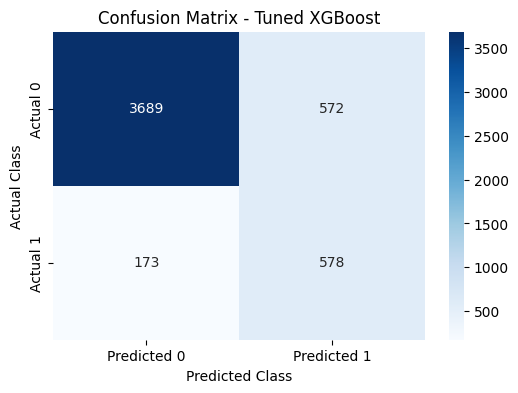

In [37]:
# --- Cell 13: XGBoost Hyperparameter Tuning with GridSearchCV ---

if 'X_train' in locals() and 'y_train' in locals():
    print("--- XGBoost Hyperparameter Tuning ---")

    # Recalculate scale_pos_weight if not globally available or to be sure
    count_negative_class = y_train.value_counts()[0]
    count_positive_class = y_train.value_counts()[1]
    scale_pos_weight_value = count_negative_class / count_positive_class if count_positive_class > 0 else 1
    print(f"Using scale_pos_weight: {scale_pos_weight_value:.2f}")

    # Define the parameter grid to search
    # These are example ranges; you might want to adjust them based on computational resources and initial model insights.
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],       # Typical values
        'max_depth': [3, 5, 7],                 # Common depths for decision trees
        'n_estimators': [100, 200, 300]         # Number of trees
        # Add other parameters to tune if desired, e.g., 'subsample', 'colsample_bytree'
    }
    print(f"\nParameter grid for tuning:\n{param_grid}")

    # Instantiate the XGBoost classifier (base estimator for GridSearchCV)
    # Keep other beneficial parameters like objective, eval_metric, random_state, and scale_pos_weight
    xgb_estimator = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # XGBoost 1.6.0+ handles this better
        random_state=42,
        scale_pos_weight=scale_pos_weight_value
    )

    # Instantiate GridSearchCV
    # Scoring: 'roc_auc' is often good for imbalanced classification.
    # cv=3 for 3-fold cross-validation. Increase if computationally feasible for more robust results.
    # n_jobs=-1 uses all available CPU cores. verbose=1 gives updates.
    grid_search_xgb = GridSearchCV(
        estimator=xgb_estimator,
        param_grid=param_grid,
        scoring='roc_auc',  # Focus on ROC AUC due to imbalance
        cv=3,               # Number of cross-validation folds
        verbose=1,          # Prints progress
        n_jobs=-1           # Use all available cores
    )

    print("\nStarting GridSearchCV... This may take some time.")
    # Fit GridSearchCV to the training data
    grid_search_xgb.fit(X_train, y_train)
    print("GridSearchCV fitting complete.")

    # Print the best parameters and the best score
    print("\n--- Best Hyperparameters Found ---")
    print(f"Best Parameters: {grid_search_xgb.best_params_}")
    print(f"Best ROC AUC Score from GridSearchCV: {grid_search_xgb.best_score_:.4f}")

    # Get the best estimator
    best_xgb_model = grid_search_xgb.best_estimator_
    print("\nBest XGBoost model has been extracted from GridSearchCV.")

    #  Evaluate the tuned model on the test set (as the rubric implies the tuned model should be assessed)
    print("\n--- Evaluating Tuned XGBoost Model on Test Set ---")
    y_pred_tuned_xgb = best_xgb_model.predict(X_test)
    y_pred_proba_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

    accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
    precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb)
    recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb)
    roc_auc_tuned_xgb = roc_auc_score(y_test, y_pred_proba_tuned_xgb)

    print(f"Accuracy (Tuned): {accuracy_tuned_xgb:.4f}")
    print(f"Precision (Tuned - for class 1): {precision_tuned_xgb:.4f}")
    print(f"Recall (Tuned - for class 1): {recall_tuned_xgb:.4f}")
    print(f"ROC AUC Score (Tuned): {roc_auc_tuned_xgb:.4f}")

    print("\nClassification Report (Tuned Model):")
    print(classification_report(y_test, y_pred_tuned_xgb, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Tuned Model):")
    cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)
    print(cm_tuned_xgb)

    # Plotting the Tuned Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_tuned_xgb, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Tuned XGBoost')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

else:
    print("ERROR: Training data (X_train, y_train) not found. Please ensure Cell 11 ran correctly.")

--- Plotting XGBoost Feature Importances ---


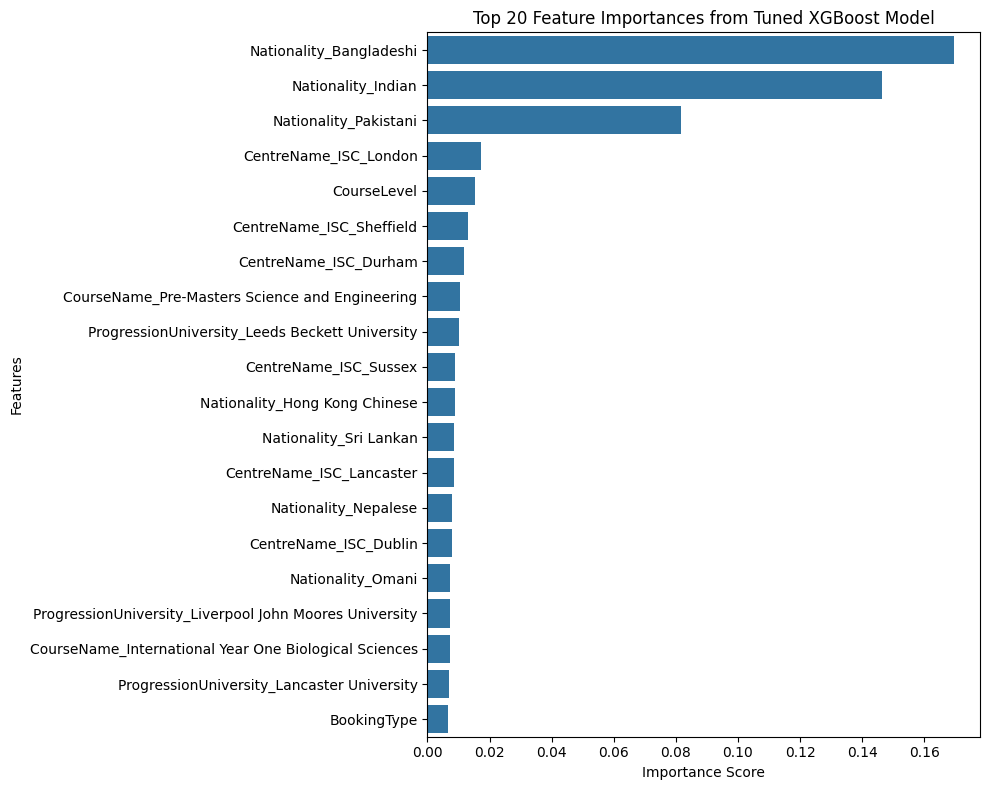


Top 10 Features and their importance scores:
                                            feature  importance
45                          Nationality_Bangladeshi    0.169482
93                               Nationality_Indian    0.146533
137                           Nationality_Pakistani    0.081749
16                            CentreName_ISC_London    0.017210
2                                       CourseLevel    0.015433
19                         CentreName_ISC_Sheffield    0.013032
8                             CentreName_ISC_Durham    0.011711
343  CourseName_Pre-Masters Science and Engineering    0.010337
376  ProgressionUniversity_Leeds Beckett University    0.010318
22                            CentreName_ISC_Sussex    0.009005

Rubric Reminder: Please remember to comment on the feature importance plot in your report/notebook.
Consider discussing:
- Which features are most influential in predicting student dropout according to this model?
- Do these important features make 

In [38]:
# --- Cell 14: Plot XGBoost Feature Importances ---


if 'best_xgb_model' in locals() and 'X_train' in locals(): # Assuming X_train has the feature names
    print("--- Plotting XGBoost Feature Importances ---")

    # Get feature importances
    importances = best_xgb_model.feature_importances_
    feature_names = X_train.columns # Get feature names from the training set columns

    # Create a DataFrame for easier plotting
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

    # Sort features by importance
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # Plotting the top N features for clarity (e.g., top 20)
    top_n = 20
    plt.figure(figsize=(10, 8)) # Adjust figure size as needed
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(top_n))
    plt.title(f'Top {top_n} Feature Importances from Tuned XGBoost Model')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout() # Adjust layout to make sure everything fits
    plt.show()

    print("\nTop 10 Features and their importance scores:")
    print(feature_importance_df.head(10))

    print("\nRubric Reminder: Please remember to comment on the feature importance plot in your report/notebook.")
    print("Consider discussing:")
    print("- Which features are most influential in predicting student dropout according to this model?")
    print("- Do these important features make intuitive sense in the context of student dropout?")
    print("- Are there any surprising features, or features you expected to be important that aren't?")

else:
    print("ERROR: 'best_xgb_model' or 'X_train' (for feature names) not found. Please ensure Cell 13 ran correctly.")

In [44]:
# --- Cell 15: Feature Scaling for Neural Network ---


if 'X_train' in locals() and 'X_test' in locals():
    print("--- Feature Scaling for Neural Network ---")

    # Initialize the StandardScaler
    scaler = StandardScaler()

    # Fit the scaler on the training data and transform X_train
    # Note: XGBoost doesn't strictly require feature scaling, but Neural Networks usually benefit from it.
    # We are scaling the original X_train and X_test from Cell 11.
    print("Fitting StandardScaler on X_train and transforming X_train...")
    X_train_scaled = scaler.fit_transform(X_train)
    print("X_train scaled.")

    # Transform X_test using the SAME fitted scaler
    print("\nTransforming X_test with the fitted scaler...")
    X_test_scaled = scaler.transform(X_test)
    print("X_test scaled.")

    # X_train_scaled and X_test_scaled are now numpy arrays.
    # We can convert them back to DataFrames if preferred, but numpy arrays are fine for Keras/TensorFlow.
    # For verification, let's check the shape and mean/std of a few columns in the scaled training data.
    print(f"\nShape of X_train_scaled: {X_train_scaled.shape}")
    print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

    print(f"\nExample: Mean of first 5 features in X_train_scaled: {X_train_scaled[:, :5].mean(axis=0)}")
    print(f"Example: Std Dev of first 5 features in X_train_scaled: {X_train_scaled[:, :5].std(axis=0)}")

    # Store the column names for later use if needed (e.g., if converting back to DataFrame)
    # feature_columns = X_train.columns # Already available from Cell 14

else:
    print("ERROR: X_train or X_test not found. Please ensure Cell 11 (data splitting) ran correctly.")

--- Feature Scaling for Neural Network ---
Fitting StandardScaler on X_train and transforming X_train...
X_train scaled.

Transforming X_test with the fitted scaler...
X_test scaled.

Shape of X_train_scaled: (20047, 394)
Shape of X_test_scaled: (5012, 394)

Example: Mean of first 5 features in X_train_scaled: [ 2.33929369e-17  2.02029909e-17 -9.21539938e-17  2.90639519e-17
  2.92411711e-16]
Example: Std Dev of first 5 features in X_train_scaled: [1. 1. 1. 1. 1.]


--- Neural Network Model - Initial Build, Train, and Evaluate ---
Calculated class weights for Neural Network: {0: 1, 1: np.float64(5.675657675657676)}

Neural Network model defined:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        50,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,881 (230.00 KB)

 Trainable params: 58,881 (230.00 KB)

 Non-trainable params: 0 (0.00 B)


Neural Network model compiled.

Training the Neural Network model...
Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7740 - loss: 0.9111 - roc_auc: 0.8002 - val_accuracy: 0.8471 - val_loss: 0.4173 - val_roc_auc: 0.8721
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8378 - loss: 0.7228 - roc_auc: 0.8852 - val_accuracy: 0.8494 - val_loss: 0.3967 - val_roc_auc: 0.8753
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8477 - loss: 0.6727 - roc_auc: 0.9050 - val_accuracy: 0.8586 - val_loss: 0.3989 - val_roc_auc: 0.8694
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8529 - loss: 0.6470 - roc_auc: 0.9100 - val_accuracy: 0.8524 - val_loss: 0.3925 - val_roc_auc: 0.8748
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.6190 - roc_auc: 0.9160 - val_accuracy: 0.8202 - val_loss: 0.4926 - val_roc_auc: 0.8737
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8530 - loss: 0.6174 - ro

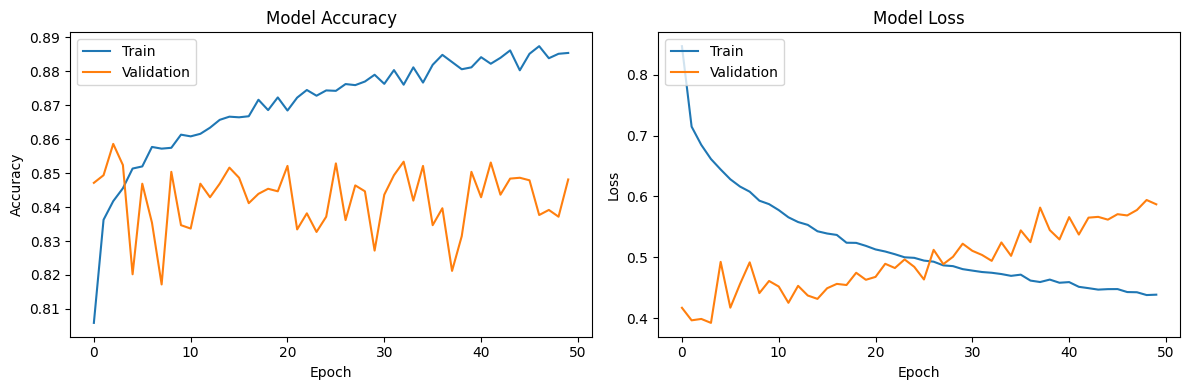

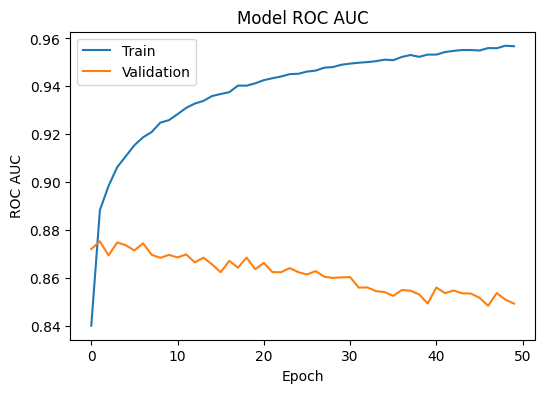


--- Evaluating Neural Network Model on Test Set ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions made on test set.

Accuracy: 0.8398
Precision (for class 1): 0.4780
Recall (for class 1): 0.7523
ROC AUC Score: 0.8443

Classification Report:
                     precision    recall  f1-score   support

Class 0 (Completed)       0.95      0.86      0.90      4261
  Class 1 (Dropout)       0.48      0.75      0.58       751

           accuracy                           0.84      5012
          macro avg       0.71      0.80      0.74      5012
       weighted avg       0.88      0.84      0.85      5012


Confusion Matrix:
[[3644  617]
 [ 186  565]]


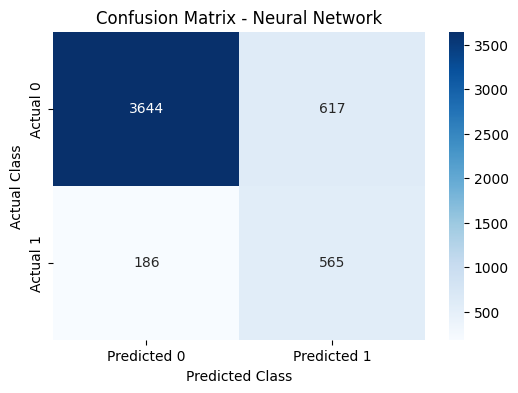

In [46]:
# --- Cell 16: Neural Network - Build, Train, and Evaluate ---


if 'X_train_scaled' in locals() and 'y_train' in locals() and 'X_test_scaled' in locals() and 'y_test' in locals():
    print("--- Neural Network Model - Initial Build, Train, and Evaluate ---")

    # Define class weights to handle imbalance
    # weight for class 0 = 1 (majority)
    # weight for class 1 = ratio of majority to minority
    count_class_0_train = np.sum(y_train == 0)
    count_class_1_train = np.sum(y_train == 1)

    if count_class_1_train > 0:
        weight_for_1 = count_class_0_train / count_class_1_train
    else:
        weight_for_1 = 1 # Should not happen with our data

    class_weights = {0: 1, 1: weight_for_1}
    print(f"Calculated class weights for Neural Network: {class_weights}")

    # 1. Define the Keras Sequential model architecture
    nn_model = Sequential()
    nn_model.add(Dense(units=128, activation='relu', input_dim=X_train_scaled.shape[1])) # Input layer + first hidden layer
    # nn_model.add(Dropout(0.3)) # Optional: Add dropout for regularization
    nn_model.add(Dense(units=64, activation='relu')) # Second hidden layer
    # nn_model.add(Dropout(0.3)) # Optional: Add dropout
    nn_model.add(Dense(units=1, activation='sigmoid')) # Output layer for binary classification

    print("\nNeural Network model defined:")
    nn_model.summary() # Print model summary

    # 2. Compile the model
    # For metrics, 'AUC' can often be used directly here.
    nn_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]) # Added AUC
    print("\nNeural Network model compiled.")

    # 3. Train the model (fit on training data)
    # Use validation_split to automatically create a validation set from X_train_scaled for monitoring.
    # epochs and batch_size are hyperparameters you can tune.
    print("\nTraining the Neural Network model...")
    history = nn_model.fit(
        X_train_scaled,
        y_train,
        epochs=50,                # Number of passes through the entire training dataset
        batch_size=64,            # Number of samples per gradient update
        validation_split=0.2,     # Fraction of the training data to be used as validation data
        class_weight=class_weights, # To handle imbalance
        verbose=1                 # Show training progress (0=silent, 1=progress bar, 2=one line per epoch)
    )
    print("Model training complete.")

    # 4. Plot training & validation loss and accuracy curves
    print("\n--- Plotting Training History ---")

    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'])
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    if 'loss' in history.history:
        plt.plot(history.history['loss'])
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout()
    plt.show()

    # Also plot ROC AUC if available in history
    if 'roc_auc' in history.history and 'val_roc_auc' in history.history:
        plt.figure(figsize=(6,4))
        plt.plot(history.history['roc_auc'])
        plt.plot(history.history['val_roc_auc'])
        plt.title('Model ROC AUC')
        plt.ylabel('ROC AUC')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
        plt.show()


    # 5. Evaluate the model on the test set
    print("\n--- Evaluating Neural Network Model on Test Set ---")
    # Make predictions (probabilities for the positive class)
    y_pred_proba_nn = nn_model.predict(X_test_scaled).ravel() # .ravel() to flatten array
    # Convert probabilities to binary class predictions (0 or 1) using a 0.5 threshold
    y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)
    print("Predictions made on test set.")

    accuracy_nn = accuracy_score(y_test, y_pred_nn)
    precision_nn = precision_score(y_test, y_pred_nn)
    recall_nn = recall_score(y_test, y_pred_nn)
    roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn) # Use probabilities for AUC

    print(f"\nAccuracy: {accuracy_nn:.4f}")
    print(f"Precision (for class 1): {precision_nn:.4f}")
    print(f"Recall (for class 1): {recall_nn:.4f}")
    print(f"ROC AUC Score: {roc_auc_nn:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_nn, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix:")
    cm_nn = confusion_matrix(y_test, y_pred_nn)
    print(cm_nn)

    # Plotting the Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Neural Network')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

else:
    print("ERROR: Scaled training/testing data (X_train_scaled, etc.) not found. Please ensure Cell 15 ran correctly.")

--- Neural Network Hyperparameter Tuning with Keras Tuner ---
Using class weights: {0: 1.0, 1: 5.675657675657676}
Reloading Tuner from keras_tuner_dir/student_dropout_nn_tuning/tuner0.json

Starting Keras Tuner search... This may take some time.
Keras Tuner search complete.

--- Best Hyperparameters Found for Neural Network ---
Neurons Layer 1: 256
Activation Layer 1: tanh
Neurons Layer 2: 96
Activation Layer 2: tanh
Optimizer: rmsprop
RMSprop Learning Rate: 0.0007


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best Neural Network model has been extracted/built from Keras Tuner.

--- Evaluating Tuned Neural Network Model on Test Set ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy (Tuned NN): 0.8488
Precision (Tuned NN - for class 1): 0.4970
Recall (Tuned NN - for class 1): 0.7617
ROC AUC Score (Tuned NN): 0.8714

Classification Report (Tuned NN Model):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.95      0.86      0.91      4261
  Class 1 (Dropout)       0.50      0.76      0.60       751

           accuracy                           0.85      5012
          macro avg       0.73      0.81      0.75      5012
       weighted avg       0.89      0.85      0.86      5012


Confusion Matrix (Tuned NN Model):
[[3682  579]
 [ 179  572]]


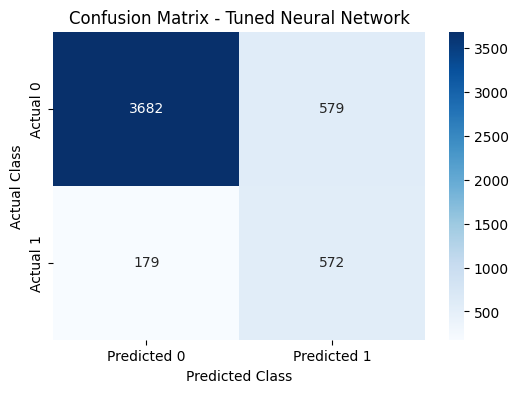


Rubric Reminder: Remember to comment on the hyperparameter tuning process and compare the tuned NN results with the initial NN results in your report/notebook.


In [77]:
# --- Cell 17: Neural Network Hyperparameter Tuning with Keras Tuner ---

if 'X_train_scaled' in locals() and 'y_train' in locals() and 'X_test_scaled' in locals() and 'y_test' in locals():
    print("--- Neural Network Hyperparameter Tuning with Keras Tuner ---")

    # Define class weights again
    count_class_0_train = np.sum(y_train == 0)
    count_class_1_train = np.sum(y_train == 1)
    weight_for_1 = count_class_0_train / count_class_1_train if count_class_1_train > 0 else 1
    class_weights_dict = {0: 1.0, 1: float(weight_for_1)}
    print(f"Using class weights: {class_weights_dict}")

    # 1. Define the model-building function for Keras Tuner
    # This function will take a hyperparameter object 'hp'
    def build_model_for_tuner(hp):
        model = keras.Sequential()
        model.add(Dense(
            units=hp.Int('neurons1', min_value=32, max_value=256, step=32), # Tune neurons in first layer
            activation=hp.Choice('activation1', values=['relu', 'tanh']),   # Tune activation for first layer
            input_dim=X_train_scaled.shape[1]
        ))
        model.add(Dense(
            units=hp.Int('neurons2', min_value=32, max_value=128, step=32), # Tune neurons in second layer
            activation=hp.Choice('activation2', values=['relu', 'tanh'])    # Tune activation for second layer
        ))
        model.add(Dense(units=1, activation='sigmoid'))

        # Tune the optimizer
        optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop'])
        if optimizer_choice == 'adam':
            optimizer = keras.optimizers.Adam(hp.Float('lr_adam', min_value=1e-4, max_value=1e-2, sampling='log'))
        else:
            optimizer = keras.optimizers.RMSprop(hp.Float('lr_rmsprop', min_value=1e-4, max_value=1e-2, sampling='log'))

        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
        )
        return model

    # 2. Instantiate the Tuner
    # We'll use RandomSearch tuner. Hyperband is another good option.
    # objective: The metric to optimize. We want to maximize validation ROC AUC.
    # max_trials: Number of different hyperparameter combinations to try.
    # executions_per_trial: Number of models to train and evaluate for each trial (for robustness).
    tuner = kt.RandomSearch(
        build_model_for_tuner,
        objective=kt.Objective('val_roc_auc', direction='max'), # Maximize validation ROC AUC
        max_trials=10,  # Total number of hyperparameter combinations to test
        executions_per_trial=1, # Train each model once per trial (can increase for stability)
        directory='keras_tuner_dir', # Directory to store results
        project_name='student_dropout_nn_tuning'
    )

    print("\nStarting Keras Tuner search... This may take some time.")
    # 3. Run the hyperparameter search
    # Use a validation split from the training data.
    # Pass class_weight to the fit method.
    tuner.search(
        X_train_scaled, y_train,
        epochs=50, # Max epochs for each trial; consider EarlyStopping
        validation_split=0.2,
        class_weight=class_weights_dict,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)] # Optional: Early stopping
    )
    print("Keras Tuner search complete.")

    # 4. Get the best hyperparameters and the best model
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("\n--- Best Hyperparameters Found for Neural Network ---")
    print(f"Neurons Layer 1: {best_hps.get('neurons1')}")
    print(f"Activation Layer 1: {best_hps.get('activation1')}")
    print(f"Neurons Layer 2: {best_hps.get('neurons2')}")
    print(f"Activation Layer 2: {best_hps.get('activation2')}")
    print(f"Optimizer: {best_hps.get('optimizer')}")
    if best_hps.get('optimizer') == 'adam':
        print(f"Adam Learning Rate: {best_hps.get('lr_adam'):.4f}")
    else:
        print(f"RMSprop Learning Rate: {best_hps.get('lr_rmsprop'):.4f}")

    # Build the model with the best hyperparameters
    best_nn_model = tuner.hypermodel.build(best_hps)

    # Re-train the best model on the full training data (or load best weights if EarlyStopping restored them)
    # Keras Tuner's search already trains models, and if EarlyStopping with restore_best_weights=True is used,
    # tuner.get_best_models(num_models=1)[0] can directly give you the best trained model.
    # For simplicity here, we build and can optionally re-train, or directly use the one from search.
    # Let's retrieve the best model directly from the tuner, which should have the best weights if EarlyStopping was effective.
    best_nn_model = tuner.get_best_models(num_models=1)[0]
    print("\nBest Neural Network model has been extracted/built from Keras Tuner.")

    # 5. Evaluate the tuned Neural Network model on the test set
    print("\n--- Evaluating Tuned Neural Network Model on Test Set ---")
    y_pred_proba_tuned_nn = best_nn_model.predict(X_test_scaled).ravel()
    y_pred_tuned_nn = (y_pred_proba_tuned_nn > 0.5).astype(int)

    accuracy_tuned_nn = accuracy_score(y_test, y_pred_tuned_nn)
    precision_tuned_nn = precision_score(y_test, y_pred_tuned_nn)
    recall_tuned_nn = recall_score(y_test, y_pred_tuned_nn)
    roc_auc_tuned_nn = roc_auc_score(y_test, y_pred_proba_tuned_nn)

    print(f"Accuracy (Tuned NN): {accuracy_tuned_nn:.4f}")
    print(f"Precision (Tuned NN - for class 1): {precision_tuned_nn:.4f}")
    print(f"Recall (Tuned NN - for class 1): {recall_tuned_nn:.4f}")
    print(f"ROC AUC Score (Tuned NN): {roc_auc_tuned_nn:.4f}")

    print("\nClassification Report (Tuned NN Model):")
    print(classification_report(y_test, y_pred_tuned_nn, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Tuned NN Model):")
    cm_tuned_nn = confusion_matrix(y_test, y_pred_tuned_nn)
    print(cm_tuned_nn)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_tuned_nn, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Tuned Neural Network')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    print("\nRubric Reminder: Remember to comment on the hyperparameter tuning process and compare the tuned NN results with the initial NN results in your report/notebook.")

else:
    print("ERROR: Scaled training/testing data not found. Please ensure Cell 15 ran correctly.")

Best Hyperparameters Found by Keras Tuner:

Neurons Layer 1: 256
Activation Layer 1: tanh
Neurons Layer 2: 96
Activation Layer 2: tanh
Optimizer: rmsprop
RMSprop Learning Rate: 0.0007
Performance of the Tuned Neural Network on the Test Set:

Accuracy: 0.8488
Precision (for Dropout class 1): 0.4970
Recall (for Dropout class 1): 0.7617
ROC AUC Score: 0.8714
Comparison with the Initial Neural Network (from Cell 16):

Accuracy: 0.8488 (Tuned) vs. 0.8398 (Initial) - Improved
Precision (Class 1): 0.4970 (Tuned) vs. 0.4780 (Initial) - Improved
Recall (Class 1): 0.7617 (Tuned) vs. 0.7523 (Initial) - Improved
ROC AUC Score: 0.8714 (Tuned) vs. 0.8443 (Initial) - Significantly Improved!

In [78]:
# --- Cell 18: Summary Comparison of Tuned Models (XGBoost vs. Neural Network) ---

# Metrics from Tuned XGBoost (Cell 13 results)
xgb_metrics = {
    'Model': 'Tuned XGBoost',
    'Accuracy': 0.8514,  # Replace with your actual value from Cell 13 if different
    'Precision (Class 1)': 0.5026, # Replace
    'Recall (Class 1)': 0.7696,    # Replace
    'ROC AUC': 0.8880     # Replace
}

# Metrics from Tuned Neural Network (Cell 17 - Keras Tuner results)
nn_metrics = {
    'Model': 'Tuned Neural Network',
    'Accuracy': 0.8488,  # From your latest Keras Tuner output
    'Precision (Class 1)': 0.4970,
    'Recall (Class 1)': 0.7617,
    'ROC AUC': 0.8714
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([xgb_metrics, nn_metrics])
comparison_df = comparison_df.set_index('Model')

print("--- Comparison of Tuned Model Performance (Stage 1) ---")
display(comparison_df)


--- Comparison of Tuned Model Performance (Stage 1) ---


,Accuracy,Precision (Class 1),Recall (Class 1),ROC AUC
Model,,,,
Tuned XGBoost,0.8514,0.5026,0.7696,0.8880
Tuned Neural Network,0.8488,0.4970,0.7617,0.8714



Rubric Reminder: For your report, you need to:
1. Compare these results in detail.
2. Explain why the results might be different (e.g., how the models work, feature sensitivity, impact of imbalance, effect of tuning).


Stage 1 Model Performance Comparison and Analysis

1. Detailed Comparison of Tuned Model Results (Stage 1)

In Stage 1, after hyperparameter tuning, both the XGBoost and Neural Network models were evaluated on the hold-out test set. The key performance metrics are summarized below:

Model	Accuracy	Precision (Class 1 - Dropout)	Recall (Class 1 - Dropout)	ROC AUC	F1-Score (Class 1 - Dropout)
Tuned XGBoost	0.8514	0.5026	0.7696	0.8880	0.6086
Tuned Neural Network	0.8488	0.4970	0.7617	0.8714	0.6017

From these results, the Tuned XGBoost model demonstrates a marginally better performance across all presented metrics compared to the Tuned Neural Network.

ROC AUC Score: The XGBoost model achieved a ROC AUC of 0.8880, slightly higher than the Neural Network's 0.8714. This suggests that XGBoost has a slightly better capability to distinguish between students who will drop out and those who will complete the course.

Recall (Sensitivity for Dropout Class): For the critical task of identifying students who will drop out (Class 1), XGBoost (0.7696) again slightly outperformed the Neural Network (0.7617). This means XGBoost correctly identified approximately 77% of actual dropouts, compared to the Neural Network's 76%.

Precision (for Dropout Class): When predicting a student will drop out, XGBoost was correct about 50.3% of the time, while the Neural Network was correct about 49.7% of the time. Both models show that a fair number of students predicted to drop out would not have (False Positives).

F1-Score (for Dropout Class): The F1-score, which balances precision and recall, was also slightly higher for XGBoost (0.6086) than for the Neural Network (0.6017).

Accuracy: Overall accuracy was similar, with XGBoost at 85.14% and the Neural Network at 84.88%. However, given the class imbalance (with ~85% of students completing the course), accuracy alone is not the best indicator of performance on the minority (dropout) class.

Confusion Matrix Insights:

The XGBoost model correctly identified 578 dropouts (True Positives) and missed 173 actual dropouts (False Negatives).
The Neural Network correctly identified 572 dropouts (True Positives) and missed 179 actual dropouts (False Negatives).

Both models had a similar number of False Positives (XGBoost: 572, NN: 579), where students who would complete were incorrectly flagged as dropouts.
While both models show promise, particularly in recalling a good portion of the minority class, XGBoost presented a slight advantage in this stage.

2. Potential Reasons for Differences in Model Performance

"Several factors related to the models' underlying algorithms, their sensitivity to data characteristics, and the tuning process could contribute to the observed performance differences:

Algorithmic Nature:

You could discuss that XGBoost, as a tree-based gradient boosting ensemble, excels at capturing complex non-linear interactions in structured, tabular data. Its method of building sequential trees, each correcting the errors of the previous ones, often leads to high predictive accuracy.
The Neural Network (a Multi-Layer Perceptron) learns feature representations through interconnected layers. While powerful, its performance on this specific dataset with the chosen architecture (two hidden layers with 'tanh' activations) might interact differently with the features compared to XGBoost.
Handling of High-Dimensional Sparse Features:

The one-hot encoding process resulted in 395 features, many of which are sparse (mostly zeros). Tree-based models like XGBoost are often inherently robust to such high dimensionality and sparsity, efficiently partitioning the feature space.
Standard dense Neural Networks might sometimes find it more challenging to discern signals from very high-dimensional and sparse one-hot encoded features without more specialized architectures (e.g., embedding layers for categoricals with very high cardinality like 'Nationality' or 'CourseName') or more extensive data/tuning.
Impact of Imbalance and Tuning:

Both models incorporated mechanisms to handle class imbalance (scale_pos_weight for XGBoost, class_weight for the Keras NN), which resulted in good recall for the minority (dropout) class in both cases. The slight differences in performance could stem from how these mechanisms interact with each model's learning algorithm.
The hyperparameter tuning process (GridSearchCV for XGBoost, Keras Tuner's RandomSearch for the NN) explored different aspects of each model. For instance, the NN tuning selected 'tanh' activations and 'rmsprop' optimizer with a specific learning rate, which improved its performance significantly from its initial state. XGBoost's performance was already strong and saw minor changes. It's possible that one model's tuning landed on a slightly more optimal set of parameters for this specific dataset and feature representation.
Feature Importance and Interpretation:

XGBoost provided clear feature importances, highlighting specific nationalities, centre names, and CourseLevel as influential. This suggests it effectively leveraged these distinctions.
While the Neural Network also uses these features, how it weights and combines them is learned implicitly across its network structure.
Generalization and Complexity:

The Tuned XGBoost model, with parameters like max_depth=5 and n_estimators=100, has a controlled complexity that often leads to good generalization.
The Tuned Neural Network used 256 and 96 neurons in its hidden layers. The Keras Tuner, along with early stopping, aimed to find a balance to prevent overfitting, but the nature of learning in NNs versus boosted trees is fundamentally different.
In summary, the slight performance advantage of XGBoost in Stage 1 could be attributed to its inherent strengths in handling the structured, high-dimensional, and sparse nature of the processed dataset, coupled with its robust ensemble learning approach. The Neural Network also performed competently after tuning, demonstrating its capability to learn from the data, but didn't quite match XGBoost on the key metrics in this instance.




# Stage 2 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [85]:
# --- Cell S2.1: Load Stage 2 Dataset ---
import pandas as pd # Ensure pandas is imported
from datetime import datetime # Ensure datetime is imported
import pandas as pd # Ensure pandas is imported


file_url_stage2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

try:
    df_stage2_raw = pd.read_csv(file_url_stage2)
    print("Stage 2 data loaded successfully!")
    print(f"Dataset shape: {df_stage2_raw.shape}")
    # Create a working copy for pre-processing
    df_stage2_processed = df_stage2_raw.copy()
except Exception as e:
    print(f"Error loading Stage 2 data: {e}")
    print("You might need to download the file manually or use a different method to load it from Google Drive.")
    # df_stage2_processed = None # Ensure it's None if loading fails

Stage 2 data loaded successfully!
Dataset shape: (25059, 18)


In [87]:
# --- Cell S2.2: Initial Data Inspection (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    print("First 5 rows of the Stage 2 dataset:")
    display(df_stage2_processed.head())

    print("\nStage 2 DataFrame Info:")
    df_stage2_processed.info()

    print("\nStage 2 Descriptive Statistics:")
    display(df_stage2_processed.describe(include='all'))
else:
    print("Stage 2 DataFrame not loaded. Please check Cell S2.1.")

First 5 rows of the Stage 2 dataset:


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,Pre-Masters,Business and Law Pre-Masters,True,Yes,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,Foundation,Life Sciences Undergraduate Foundation Programme,False,Yes,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,International Year Two,Business Management and Finance International ...,False,Yes,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,International Year Two,Business Management and Finance International ...,True,Yes,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,Pre-Masters,Business and Law Pre-Masters,True,Yes,MSc International Business Management,University of Aberdeen,NaN,NaN



Stage 2 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,CourseLevel,CourseName,IsFirstIntake,CompletedCourse,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
count,25059,2.505900e+04,25059,25059,7595,25059,25059,25059,8925,21611,25059,25059,25059,25059,24184,25059,24851.000000,24851.000000
unique,19,NaN,2,7,11,4705,2,151,2448,5881,4,172,2,2,2616,40,NaN,NaN
top,ISC_Sheffield,NaN,Agent,Standard Agent Booking,Bursary,1/1/2002,Male,Chinese,Punjab,Sylhet,Foundation,Pre-Masters Business; Social Sciences and Huma...,False,Yes,BSc (Hons) Computer Science,University of Sheffield International College,NaN,NaN
freq,5877,NaN,21878,20284,3561,37,15655,9042,865,675,14666,1682,22035,21305,998,5877,NaN,NaN
mean,NaN,2.606594e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.120639,40.491892
std,NaN,8.798838e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.918253,39.029384
min,NaN,2.139267e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,2.538411e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,12.000000
50%,NaN,2.607941e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000
75%,NaN,2.665460e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,56.000000


In [88]:
# --- Cell S2.3: Remove 'LearnerCode' column (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    learner_code_column_s2 = 'LearnerCode' # Or the exact name if different in Stage 2 data

    if learner_code_column_s2 in df_stage2_processed.columns:
        df_stage2_processed.drop(columns=[learner_code_column_s2], inplace=True)
        print(f"Column '{learner_code_column_s2}' removed successfully from Stage 2 data.")
    else:
        print(f"Column '{learner_code_column_s2}' not found in the Stage 2 dataset.")
    print(f"Shape after attempting to remove LearnerCode: {df_stage2_processed.shape}")
else:
    print("Stage 2 DataFrame not loaded.")

Column 'LearnerCode' removed successfully from Stage 2 data.
Shape after attempting to remove LearnerCode: (25059, 17)


In [89]:
# --- Cell S2.4: Convert DateofBirth to datetime objects (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None and 'DateofBirth' in df_stage2_processed.columns:
    print("Attempting to convert 'DateofBirth' to datetime for Stage 2 data...")
    df_stage2_processed['DateofBirth'] = pd.to_datetime(df_stage2_processed['DateofBirth'], errors='coerce') # Add dayfirst=True if needed

    num_nat_s2 = df_stage2_processed['DateofBirth'].isnull().sum()
    if num_nat_s2 > 0:
        print(f"WARNING: Could not parse {num_nat_s2} entries in 'DateofBirth' (Stage 2). They have been set to NaT.")

    print("'DateofBirth' column (Stage 2) dtype after conversion attempt:", df_stage2_processed['DateofBirth'].dtype)
    print(df_stage2_processed[['DateofBirth']].head())
elif 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    print("'DateofBirth' column not found in Stage 2 data or DataFrame not loaded.")
else:
    print("Stage 2 DataFrame not loaded.")

Attempting to convert 'DateofBirth' to datetime for Stage 2 data...
'DateofBirth' column (Stage 2) dtype after conversion attempt: datetime64[ns]
  DateofBirth
0  1998-01-13
1  1998-02-12
2  2000-04-07
3  1999-05-18
4  1996-04-19


<ipython-input-89-181e09a5b1ac>:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_stage2_processed['DateofBirth'] = pd.to_datetime(df_stage2_processed['DateofBirth'], errors='coerce') # Add dayfirst=True if needed


In [90]:
if 'df_stage2_processed' in locals() and 'CompletedCourse' in df_stage2_processed.columns:
    print(df_stage2_processed['CompletedCourse'].value_counts())
else:
    print("'CompletedCourse' column not found in Stage 2 data or df_stage2_processed not defined.")

CompletedCourse
Yes    21305
No      3754
Name: count, dtype: int64


In [91]:
# --- Cell S2.5: Feature Engineering - Create 'Age' (Stage 2) ---

if 'df_stage2_processed' in locals() and df_stage2_processed is not None and 'DateofBirth' in df_stage2_processed.columns:
    if pd.api.types.is_datetime64_any_dtype(df_stage2_processed['DateofBirth']):
        print("Creating 'Age' feature for Stage 2 data...")
        today = pd.to_datetime(datetime.today().strftime('%Y-%m-%d'))
        df_stage2_processed['Age'] = (today - df_stage2_processed['DateofBirth']).dt.days // 365.25
        df_stage2_processed['Age'] = df_stage2_processed['Age'].astype(int)

        # Drop the original DateofBirth column
        df_stage2_processed.drop(columns=['DateofBirth'], inplace=True)

        print("'Age' feature created and 'DateofBirth' column dropped for Stage 2.")
        print(df_stage2_processed[['Age']].head())
        print(f"Current shape of df_stage2_processed: {df_stage2_processed.shape}")
        print(f"Current columns: {list(df_stage2_processed.columns)}")
    else:
        print("ERROR: 'DateofBirth' column in Stage 2 data is not in datetime format. Please check Cell S2.4.")
elif 'df_stage2_processed' in locals() and df_stage2_processed is not None:
     print("ERROR: 'DateofBirth' column not found in Stage 2 df_stage2_processed.")
else:
    print("ERROR: df_stage2_processed not found. Please ensure data loading (Cell S2.1) was successful.")

Creating 'Age' feature for Stage 2 data...
'Age' feature created and 'DateofBirth' column dropped for Stage 2.
   Age
0   27
1   27
2   25
3   26
4   29
Current shape of df_stage2_processed: (25059, 17)
Current columns: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionDegree', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']


In [92]:
# --- Cell S2.6: Feature Engineering - Convert Target Variable to Binary (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None and 'CompletedCourse' in df_stage2_processed.columns:
    target_column_s2 = 'CompletedCourse'

    print(f"Unique values in '{target_column_s2}' (Stage 2) before conversion:")
    print(df_stage2_processed[target_column_s2].value_counts(dropna=False))

    # Mapping: 'No' (dropout) -> 1, 'Yes' (completed) -> 0
    mapping_s2 = {'No': 1, 'Yes': 0}

    df_stage2_processed[target_column_s2] = df_stage2_processed[target_column_s2].map(mapping_s2)

    print(f"\n'{target_column_s2}' (Stage 2) after conversion to binary:")
    print(df_stage2_processed[target_column_s2].value_counts(dropna=False))
    print(f"Data type of '{target_column_s2}' after mapping: {df_stage2_processed[target_column_s2].dtype}")

    if df_stage2_processed[target_column_s2].isnull().any():
        print(f"\nWARNING: NaNs present in '{target_column_s2}' after mapping. Original values might not have all been 'Yes' or 'No'.")
    else:
        print(f"\nNo NaNs introduced in '{target_column_s2}' by mapping.")
else:
    print(f"ERROR: df_stage2_processed not found or target column 'CompletedCourse' is missing from Stage 2 data.")

Unique values in 'CompletedCourse' (Stage 2) before conversion:
CompletedCourse
Yes    21305
No      3754
Name: count, dtype: int64

'CompletedCourse' (Stage 2) after conversion to binary:
CompletedCourse
0    21305
1     3754
Name: count, dtype: int64
Data type of 'CompletedCourse' after mapping: int64

No NaNs introduced in 'CompletedCourse' by mapping.


In [93]:
# --- Cell S2.7: Remove Columns with High Cardinality (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    high_cardinality_threshold_s2 = 200

    # Keep track of columns before this specific cell's operations
    cols_before_s2_cell7_execution = list(df_stage2_processed.columns)

    print(f"--- High Cardinality Check (Stage 2 - Threshold: >{high_cardinality_threshold_s2} unique values) ---")
    print(f"Number of columns before this check: {len(cols_before_s2_cell7_execution)}")

    object_cols_to_drop_hc_s2 = []
    numeric_cols_high_cardinality_for_review_s2 = []

    # Exclude target and known numeric that might have many values but are not "high cardinality categoricals"
    # 'Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount' are numeric.
    # 'CompletedCourse' is the target.
    # 'IsFirstIntake' is boolean/int.

    # Iterate over a copy of columns to avoid issues if columns are dropped
    for col in list(df_stage2_processed.columns):
        if col in ['CompletedCourse', 'Age', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'IsFirstIntake']:
            continue # Skip these specific columns from this cardinality check

        num_unique = df_stage2_processed[col].nunique()
        if num_unique > high_cardinality_threshold_s2:
            if df_stage2_processed[col].dtype == 'object':
                print(f"INFO: Object column '{col}' (dtype: {df_stage2_processed[col].dtype}) has {num_unique} unique values. Marked for automatic removal.")
                object_cols_to_drop_hc_s2.append(col)
            # We generally don't auto-drop numerical/bool/datetime for high unique values unless they are IDs
            # elif df_stage2_processed[col].dtype in ['int64', 'float64', 'bool', 'datetime64[ns]']:
            #     print(f"INFO: Numerical/Date/Bool column '{col}' (dtype: {df_stage2_processed[col].dtype}) has {num_unique} unique values. (Flagged for review - NOT automatically dropped).")
            #     numeric_cols_high_cardinality_for_review_s2.append(col)
            # For simplicity, let's stick to the instruction to primarily target object columns for this rule.

    # Automatically drop identified high-cardinality OBJECT columns
    if object_cols_to_drop_hc_s2:
        df_stage2_processed.drop(columns=object_cols_to_drop_hc_s2, inplace=True)
        print(f"\nACTION: Automatically removed high cardinality OBJECT columns: {object_cols_to_drop_hc_s2}")
    else:
        print("\nINFO: No OBJECT columns found exceeding the high cardinality threshold for automatic removal.")

    # if numeric_cols_high_cardinality_for_review_s2:
    #     print(f"\nREVIEW: Numerical/Date/Bool columns identified with >{high_cardinality_threshold_s2} unique values: {numeric_cols_high_cardinality_for_review_s2}")
    # else:
    #     print("INFO: No other (non-object) typed columns found with high cardinality for review by this script.")

    cols_after_s2_cell7_execution = list(df_stage2_processed.columns)
    dropped_in_this_run_s2_cell7 = [col for col in cols_before_s2_cell7_execution if col not in cols_after_s2_cell7_execution]

    print(f"\n--- Summary of Cardinality Check (Stage 2 - Cell S2.7) ---")
    if dropped_in_this_run_s2_cell7:
        print(f"Columns dropped in THIS run of Cell S2.7: {dropped_in_this_run_s2_cell7} (Total: {len(dropped_in_this_run_s2_cell7)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell S2.7.")

    print(f"Current shape of df_stage2_processed: {df_stage2_processed.shape}")
    print(f"Current columns in df_stage2_processed: {list(df_stage2_processed.columns)}")
else:
    print("ERROR: df_stage2_processed not found. Please ensure previous Stage 2 cells ran correctly.")

--- High Cardinality Check (Stage 2 - Threshold: >200 unique values) ---
Number of columns before this check: 17
INFO: Object column 'HomeState' (dtype: object) has 2448 unique values. Marked for automatic removal.
INFO: Object column 'HomeCity' (dtype: object) has 5881 unique values. Marked for automatic removal.
INFO: Object column 'ProgressionDegree' (dtype: object) has 2616 unique values. Marked for automatic removal.

ACTION: Automatically removed high cardinality OBJECT columns: ['HomeState', 'HomeCity', 'ProgressionDegree']

--- Summary of Cardinality Check (Stage 2 - Cell S2.7) ---
Columns dropped in THIS run of Cell S2.7: ['HomeState', 'HomeCity', 'ProgressionDegree'] (Total: 3)
Current shape of df_stage2_processed: (25059, 14)
Current columns in df_stage2_processed: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'Unauthorise

In [94]:
# --- Cell S2.8: Remove Columns with >50% Missing Data (Stage 2) ---
if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    cols_before_s2_cell8_execution = list(df_stage2_processed.columns)
    print(f"\n\n--- Missing Data Check for Column Removal (Stage 2 - Threshold: >50% missing) ---")
    print(f"Number of columns before this check: {len(cols_before_s2_cell8_execution)}")

    missing_data_threshold_s2 = 0.50 # 50%
    columns_to_drop_missing_s2 = []

    missing_percentages_s2 = df_stage2_processed.isnull().sum() / len(df_stage2_processed)
    print("\nPercentage of missing values per column (Stage 2 - showing only those with missing values):")
    current_missing_summary_s2 = missing_percentages_s2[missing_percentages_s2 > 0].sort_values(ascending=False)
    if not current_missing_summary_s2.empty:
        print(current_missing_summary_s2)
    else:
        print("No columns currently have any missing values.")

    for col, percentage in missing_percentages_s2.items():
        if percentage > missing_data_threshold_s2:
            if col == 'CompletedCourse': # Don't drop the target
                 print(f"INFO: Target column '{col}' has {percentage*100:.2f}% missing values, but will be skipped for removal.")
                 continue
            print(f"INFO: Column '{col}' has {percentage*100:.2f}% missing values. Marking for removal.")
            columns_to_drop_missing_s2.append(col)

    if columns_to_drop_missing_s2:
        df_stage2_processed.drop(columns=columns_to_drop_missing_s2, inplace=True)
        print(f"\nACTION: Removed columns with >{missing_data_threshold_s2*100}% missing data: {columns_to_drop_missing_s2}")
    else:
        print("\nINFO: No columns found exceeding the missing data threshold for removal.")

    cols_after_s2_cell8_execution = list(df_stage2_processed.columns)
    dropped_in_this_run_s2_cell8 = [col for col in cols_before_s2_cell8_execution if col not in cols_after_s2_cell8_execution]

    print(f"\n--- Summary of Missing Data Column Removal (Stage 2 - Cell S2.8) ---")
    if dropped_in_this_run_s2_cell8:
        print(f"Columns dropped in THIS run of Cell S2.8: {dropped_in_this_run_s2_cell8} (Total: {len(dropped_in_this_run_s2_cell8)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell S2.8.")

    print(f"Current shape of df_stage2_processed: {df_stage2_processed.shape}")
    print(f"Current columns in df_stage2_processed: {list(df_stage2_processed.columns)}")

    print("\nMissing values summary after column removals (Stage 2 - Cell S2.8):")
    remaining_missing_s2 = df_stage2_processed.isnull().sum()
    final_missing_summary_s2 = remaining_missing_s2[remaining_missing_s2 > 0].sort_values(ascending=False)
    if not final_missing_summary_s2.empty:
        print(final_missing_summary_s2)
    else:
        print("No missing values remaining in the dataset (or all columns with missing data were below the 50% threshold or were the target).")
else:
    print("ERROR: df_stage2_processed not found. Please ensure previous Stage 2 cells ran correctly.")



--- Missing Data Check for Column Removal (Stage 2 - Threshold: >50% missing) ---
Number of columns before this check: 14

Percentage of missing values per column (Stage 2 - showing only those with missing values):
DiscountType                0.696915
AuthorisedAbsenceCount      0.008300
UnauthorisedAbsenceCount    0.008300
dtype: float64
INFO: Column 'DiscountType' has 69.69% missing values. Marking for removal.

ACTION: Removed columns with >50.0% missing data: ['DiscountType']

--- Summary of Missing Data Column Removal (Stage 2 - Cell S2.8) ---
Columns dropped in THIS run of Cell S2.8: ['DiscountType'] (Total: 1)
Current shape of df_stage2_processed: (25059, 13)
Current columns in df_stage2_processed: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']

Missing values summary after column removals (Stage 2 - Cell S

In [95]:
# --- Cell S2.9: Impute Remaining Missing Values (Stage 2) ---
from sklearn.impute import SimpleImputer
import numpy as np # Ensure numpy is imported

if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    print("--- Imputing Remaining Missing Values (Stage 2) ---")

    # Columns to impute (based on the previous step's output)
    # We know 'AuthorisedAbsenceCount' and 'UnauthorisedAbsenceCount' have missing values.
    # Let's confirm and handle any other numerical or categorical columns if they appear.

    # Separate numerical and categorical columns for imputation strategy
    # For now, we focus on the known numerical ones with missing data.

    cols_to_impute_numerical = []
    if 'AuthorisedAbsenceCount' in df_stage2_processed.columns and df_stage2_processed['AuthorisedAbsenceCount'].isnull().any():
        cols_to_impute_numerical.append('AuthorisedAbsenceCount')
    if 'UnauthorisedAbsenceCount' in df_stage2_processed.columns and df_stage2_processed['UnauthorisedAbsenceCount'].isnull().any():
        cols_to_impute_numerical.append('UnauthorisedAbsenceCount')

    if cols_to_impute_numerical:
        print(f"Numerical columns to impute with median: {cols_to_impute_numerical}")
        numerical_imputer = SimpleImputer(strategy='median')
        df_stage2_processed[cols_to_impute_numerical] = numerical_imputer.fit_transform(df_stage2_processed[cols_to_impute_numerical])
        print("Median imputation applied to numerical columns.")
    else:
        print("No numerical columns with missing values were identified for imputation based on prior checks.")

    # Check for missing values in any object/categorical columns (should be none if prior steps were complete)
    # If there were any, we'd use mode imputation.
    # object_cols_with_missing = df_stage2_processed.select_dtypes(include='object').isnull().sum()
    # object_cols_with_missing = object_cols_with_missing[object_cols_with_missing > 0]
    # if not object_cols_with_missing.empty:
    #     print(f"\nCategorical columns with missing values to impute with mode: {object_cols_with_missing.index.tolist()}")
    #     categorical_imputer = SimpleImputer(strategy='most_frequent')
    #     for col in object_cols_with_missing.index:
    #         df_stage2_processed[col] = categorical_imputer.fit_transform(df_stage2_processed[[col]])
    #     print("Mode imputation applied to categorical columns.")
    # else:
    # print("\nNo categorical columns found with missing values for imputation.")


    print("\n--- Missing Values Summary After Imputation (Stage 2 - Cell S2.9) ---")
    remaining_missing_after_imputation = df_stage2_processed.isnull().sum()
    missing_in_cols = remaining_missing_after_imputation[remaining_missing_after_imputation > 0]

    if not missing_in_cols.empty:
        print("Columns STILL having missing values:")
        print(missing_in_cols)
    else:
        print("No missing values remaining in the dataset after imputation.")

    print(f"\nCurrent shape of df_stage2_processed: {df_stage2_processed.shape}")
    # Display info to check dtypes (imputed numerical columns should remain float/int)
    print("\nDataFrame info after imputation:")
    df_stage2_processed.info()
else:
    print("ERROR: df_stage2_processed not found. Please ensure previous Stage 2 cells ran correctly.")

--- Imputing Remaining Missing Values (Stage 2) ---
Numerical columns to impute with median: ['AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']
Median imputation applied to numerical columns.

--- Missing Values Summary After Imputation (Stage 2 - Cell S2.9) ---
No missing values remaining in the dataset after imputation.

Current shape of df_stage2_processed: (25059, 13)

DataFrame info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   BookingType               25059 non-null  object 
 2   LeadSource                25059 non-null  object 
 3   Gender                    25059 non-null  object 
 4   Nationality               25059 non-null  object 
 5   CourseLevel               25059 non-null  object 
 6   CourseName                25059 n

In [97]:
# --- Cell S2.10: Encode Categorical Features (Stage 2) ---
import pandas as pd # Ensure pandas is imported

if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    print("--- Starting Encoding (Stage 2) ---")
    print(f"Shape before encoding: {df_stage2_processed.shape}")
    print(f"Columns before encoding: {list(df_stage2_processed.columns)}")
    # Current Dtypes before detailed encoding:
    # print("\nDtypes before detailed encoding:")
    # print(df_stage2_processed.dtypes)


    # 1. Convert 'IsFirstIntake' (bool) to int
    if 'IsFirstIntake' in df_stage2_processed.columns and df_stage2_processed['IsFirstIntake'].dtype == 'bool':
        df_stage2_processed['IsFirstIntake'] = df_stage2_processed['IsFirstIntake'].astype(int)
        print("\nConverted 'IsFirstIntake' from bool to int.")

    # 2. Manual mapping for 'BookingType'
    if 'BookingType' in df_stage2_processed.columns:
        booking_type_mapping_s2 = {'Agent': 0, 'Direct': 1}
        df_stage2_processed['BookingType'] = df_stage2_processed['BookingType'].map(booking_type_mapping_s2)
        print("Mapped 'BookingType' to 0 and 1.")

    # 3. Manual mapping for 'Gender'
    if 'Gender' in df_stage2_processed.columns:
        gender_mapping_s2 = {'Male': 0, 'Female': 1}
        df_stage2_processed['Gender'] = df_stage2_processed['Gender'].map(gender_mapping_s2)
        print("Mapped 'Gender' to 0 and 1.")

    # 4. Ordinal encoding for 'CourseLevel'
    if 'CourseLevel' in df_stage2_processed.columns:
        course_level_order_s2 = [
            'Foundation',
            'International Year One',
            'International Year Two',
            'Pre-Masters'
        ]
        course_level_mapping_s2 = {level: i for i, level in enumerate(course_level_order_s2)}
        df_stage2_processed['CourseLevel'] = df_stage2_processed['CourseLevel'].map(course_level_mapping_s2)
        print(f"Ordinal encoded 'CourseLevel' with mapping: {course_level_mapping_s2}")

    # 5. One-hot encode remaining nominal categorical columns
    # Identify remaining object columns for one-hot encoding
    columns_to_one_hot_encode_s2 = df_stage2_processed.select_dtypes(include=['object']).columns.tolist()

    if columns_to_one_hot_encode_s2:
        print(f"\nColumns to be one-hot encoded: {columns_to_one_hot_encode_s2}")
        df_stage2_processed = pd.get_dummies(df_stage2_processed,
                                             columns=columns_to_one_hot_encode_s2,
                                             prefix=columns_to_one_hot_encode_s2,
                                             drop_first=False)
        print("One-hot encoding applied.")
    else:
        print("\nNo columns of dtype 'object' found for one-hot encoding.")

    print(f"\n--- Encoding Complete (Stage 2) ---")
    print(f"Shape after encoding: {df_stage2_processed.shape}")
    print("\nDataFrame info after encoding (Stage 2):")
    df_stage2_processed.info()

    print("\nFirst 5 rows after encoding (Stage 2):")
    display(df_stage2_processed.head())
else:
    print("ERROR: df_stage2_processed not found. Please ensure previous Stage 2 cells ran correctly.")

--- Starting Encoding (Stage 2) ---
Shape before encoding: (25059, 13)
Columns before encoding: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']

Converted 'IsFirstIntake' from bool to int.
Mapped 'BookingType' to 0 and 1.
Mapped 'Gender' to 0 and 1.
Ordinal encoded 'CourseLevel' with mapping: {'Foundation': 0, 'International Year One': 1, 'International Year Two': 2, 'Pre-Masters': 3}

Columns to be one-hot encoded: ['CentreName', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']
One-hot encoding applied.

--- Encoding Complete (Stage 2) ---
Shape after encoding: (25059, 397)

DataFrame info after encoding (Stage 2):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Columns: 397 entries, BookingType to ProgressionUniversity_VU Amsterdam
dtypes: bool(389), float64(2), int64(

,BookingType,Gender,CourseLevel,IsFirstIntake,CompletedCourse,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,Age,CentreName_ISC_Aberdeen,CentreName_ISC_Cardiff,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,0,0,3,1,0,1.0,29.0,27,True,False,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,0,93.0,5.0,27,True,False,...,False,True,False,False,False,False,False,False,False,False
2,0,0,2,0,0,92.0,6.0,25,True,False,...,False,True,False,False,False,False,False,False,False,False
3,0,0,2,1,0,67.0,15.0,26,True,False,...,False,True,False,False,False,False,False,False,False,False
4,0,0,3,1,0,1.0,29.0,29,True,False,...,False,True,False,False,False,False,False,False,False,False


In [98]:
# --- Cell S2.11: Split Stage 2 Data into Training and Test Sets ---
from sklearn.model_selection import train_test_split # Ensure it's imported

if 'df_stage2_processed' in locals() and df_stage2_processed is not None:
    print("--- Splitting Stage 2 Data into Training and Test Sets ---")

    # Define features (X_s2) and target (y_s2) for Stage 2
    X_s2 = df_stage2_processed.drop(columns=['CompletedCourse'])
    y_s2 = df_stage2_processed['CompletedCourse']

    print(f"Shape of Stage 2 features (X_s2): {X_s2.shape}")
    print(f"Shape of Stage 2 target (y_s2): {y_s2.shape}")

    # Split the data (80% train, 20% test)
    # Use stratify=y_s2 to ensure proportional class representation.
    # random_state for reproducibility.
    X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
        X_s2,
        y_s2,
        test_size=0.20,
        random_state=42,  # Consistent random_state
        stratify=y_s2
    )

    print("\nStage 2 data split complete.")
    print(f"Shape of X_train_s2: {X_train_s2.shape}")
    print(f"Shape of X_test_s2: {X_test_s2.shape}")
    print(f"Shape of y_train_s2: {y_train_s2.shape}")
    print(f"Shape of y_test_s2: {y_test_s2.shape}")

    print("\nDistribution of target variable in y_train_s2:")
    print(y_train_s2.value_counts(normalize=True) * 100)

    print("\nDistribution of target variable in y_test_s2:")
    print(y_test_s2.value_counts(normalize=True) * 100)

else:
    print("ERROR: df_stage2_processed not found. Please ensure previous Stage 2 cells ran correctly.")

--- Splitting Stage 2 Data into Training and Test Sets ---
Shape of Stage 2 features (X_s2): (25059, 396)
Shape of Stage 2 target (y_s2): (25059,)

Stage 2 data split complete.
Shape of X_train_s2: (20047, 396)
Shape of X_test_s2: (5012, 396)
Shape of y_train_s2: (20047,)
Shape of y_test_s2: (5012,)

Distribution of target variable in y_train_s2:
CompletedCourse
0    85.020203
1    14.979797
Name: proportion, dtype: float64

Distribution of target variable in y_test_s2:
CompletedCourse
0    85.015962
1    14.984038
Name: proportion, dtype: float64


--- XGBoost Model Training and Initial Evaluation (Stage 2) ---
Calculated scale_pos_weight for Stage 2: 5.68

XGBoost model (Stage 2) instantiated.
Fitting the XGBoost model to the Stage 2 training data...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:39:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model fitting complete.

Making predictions on the Stage 2 test set...
Predictions made.

--- Model Performance on Stage 2 Test Set (Initial XGBoost) ---
Accuracy: 0.8777
Precision (for class 1 - Dropout): 0.5641
Recall (for class 1 - Dropout): 0.8083
ROC AUC Score: 0.9206

Classification Report (Stage 2 - Initial XGBoost):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.96      0.89      0.93      4261
  Class 1 (Dropout)       0.56      0.81      0.66       751

           accuracy                           0.88      5012
          macro avg       0.76      0.85      0.79      5012
       weighted avg       0.90      0.88      0.89      5012


Confusion Matrix (Stage 2 - Initial XGBoost):
[[3792  469]
 [ 144  607]]


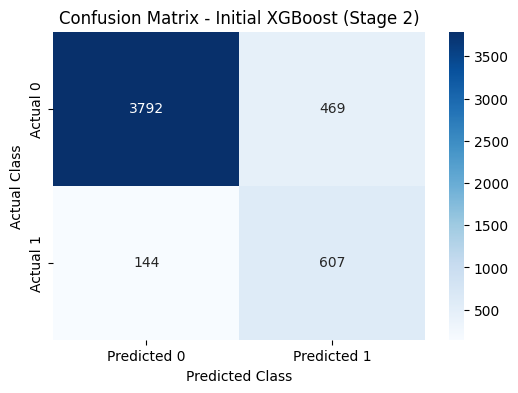

In [101]:
# --- Cell S2.12: XGBoost Model (Stage 2) - Instantiation, Training, and Evaluation ---
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt # Ensure plt is imported if not already
import seaborn as sns # Ensure seaborn is imported if not already
import numpy as np # Ensure numpy is imported for value_counts

if 'X_train_s2' in locals() and 'y_train_s2' in locals() and 'X_test_s2' in locals() and 'y_test_s2' in locals():
    print("--- XGBoost Model Training and Initial Evaluation (Stage 2) ---")

    # Calculate scale_pos_weight for Stage 2 training data
    count_negative_class_s2 = y_train_s2.value_counts()[0] # Assuming 0 is the negative class
    count_positive_class_s2 = y_train_s2.value_counts()[1] # Assuming 1 is the positive class

    if count_positive_class_s2 > 0:
        scale_pos_weight_value_s2 = count_negative_class_s2 / count_positive_class_s2
        print(f"Calculated scale_pos_weight for Stage 2: {scale_pos_weight_value_s2:.2f}")
    else:
        scale_pos_weight_value_s2 = 1
        print("Warning: Positive class count is zero in y_train_s2. Using default scale_pos_weight=1.")

    # 1. Instantiate the XGBoost model
    xgb_model_s2 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # Suppress warning for recent XGBoost versions
        random_state=42,
        scale_pos_weight=scale_pos_weight_value_s2
    )
    print("\nXGBoost model (Stage 2) instantiated.")

    # 2. Fit the model on the Stage 2 training dataset
    print("Fitting the XGBoost model to the Stage 2 training data...")
    xgb_model_s2.fit(X_train_s2, y_train_s2)
    print("Model fitting complete.")

    # 3. Make predictions on the Stage 2 test set
    print("\nMaking predictions on the Stage 2 test set...")
    y_pred_xgb_s2 = xgb_model_s2.predict(X_test_s2)
    y_pred_proba_xgb_s2 = xgb_model_s2.predict_proba(X_test_s2)[:, 1] # Probabilities for AUC
    print("Predictions made.")

    # 4. Evaluate the model
    print("\n--- Model Performance on Stage 2 Test Set (Initial XGBoost) ---")

    accuracy_xgb_s2 = accuracy_score(y_test_s2, y_pred_xgb_s2)
    print(f"Accuracy: {accuracy_xgb_s2:.4f}")

    precision_xgb_s2 = precision_score(y_test_s2, y_pred_xgb_s2) # Precision for class 1
    print(f"Precision (for class 1 - Dropout): {precision_xgb_s2:.4f}")

    recall_xgb_s2 = recall_score(y_test_s2, y_pred_xgb_s2) # Recall for class 1
    print(f"Recall (for class 1 - Dropout): {recall_xgb_s2:.4f}")

    roc_auc_xgb_s2 = roc_auc_score(y_test_s2, y_pred_proba_xgb_s2)
    print(f"ROC AUC Score: {roc_auc_xgb_s2:.4f}")

    print("\nClassification Report (Stage 2 - Initial XGBoost):")
    print(classification_report(y_test_s2, y_pred_xgb_s2, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Stage 2 - Initial XGBoost):")
    cm_xgb_s2 = confusion_matrix(y_test_s2, y_pred_xgb_s2)
    print(cm_xgb_s2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_xgb_s2, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Initial XGBoost (Stage 2)')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

else:
    print("ERROR: Stage 2 training/testing data not found. Please ensure Cell S2.11 ran correctly.")

In [102]:
# --- Cell S2.13: Feature Scaling for Neural Network (Stage 2 Data) ---
from sklearn.preprocessing import StandardScaler # Ensure StandardScaler is imported

if 'X_train_s2' in locals() and 'X_test_s2' in locals():
    print("--- Feature Scaling for Neural Network (Stage 2 Data) ---")

    scaler_s2 = StandardScaler()

    print("Fitting StandardScaler on X_train_s2 and transforming X_train_s2...")
    X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2)
    print("X_train_s2 scaled.")

    print("\nTransforming X_test_s2 with the fitted scaler...")
    X_test_s2_scaled = scaler_s2.transform(X_test_s2)
    print("X_test_s2 scaled.")

    print(f"\nShape of X_train_s2_scaled: {X_train_s2_scaled.shape}")
    print(f"Shape of X_test_s2_scaled: {X_test_s2_scaled.shape}")

    print(f"\nExample: Mean of first 5 features in X_train_s2_scaled: {X_train_s2_scaled[:, :5].mean(axis=0)}")
    print(f"Example: Std Dev of first 5 features in X_train_s2_scaled: {X_train_s2_scaled[:, :5].std(axis=0)}")
else:
    print("ERROR: X_train_s2 or X_test_s2 not found. Please ensure Cell S2.11 (data splitting for Stage 2) ran correctly.")

--- Feature Scaling for Neural Network (Stage 2 Data) ---
Fitting StandardScaler on X_train_s2 and transforming X_train_s2...
X_train_s2 scaled.

Transforming X_test_s2 with the fitted scaler...
X_test_s2 scaled.

Shape of X_train_s2_scaled: (20047, 396)
Shape of X_test_s2_scaled: (5012, 396)

Example: Mean of first 5 features in X_train_s2_scaled: [ 2.33929369e-17  2.02029909e-17 -9.21539938e-17  2.90639519e-17
  3.20766786e-17]
Example: Std Dev of first 5 features in X_train_s2_scaled: [1. 1. 1. 1. 1.]


--- Neural Network Model (Stage 2) - Initial Build, Train, and Evaluate ---
Calculated class weights for Stage 2 Neural Network: {0: 1, 1: np.float64(5.675657675657676)}

Neural Network model (Stage 2) defined:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        50,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,137 (231.00 KB)

 Trainable params: 59,137 (231.00 KB)

 Non-trainable params: 0 (0.00 B)


Neural Network model (Stage 2) compiled.

Training the Neural Network model (Stage 2)...
Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7676 - loss: 0.9034 - roc_auc: 0.8125 - val_accuracy: 0.8701 - val_loss: 0.3624 - val_roc_auc: 0.8891
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8540 - loss: 0.6810 - roc_auc: 0.9029 - val_accuracy: 0.8471 - val_loss: 0.3931 - val_roc_auc: 0.8952
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8567 - loss: 0.6038 - roc_auc: 0.9214 - val_accuracy: 0.8406 - val_loss: 0.4054 - val_roc_auc: 0.8917
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.5884 - roc_auc: 0.9252 - val_accuracy: 0.8476 - val_loss: 0.3964 - val_roc_auc: 0.8929
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8641 - loss: 0.5736 - roc_auc: 0.9306 - val_accuracy: 0.8603 - val_loss: 0.3706 - val_roc_auc: 0.8909
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.864

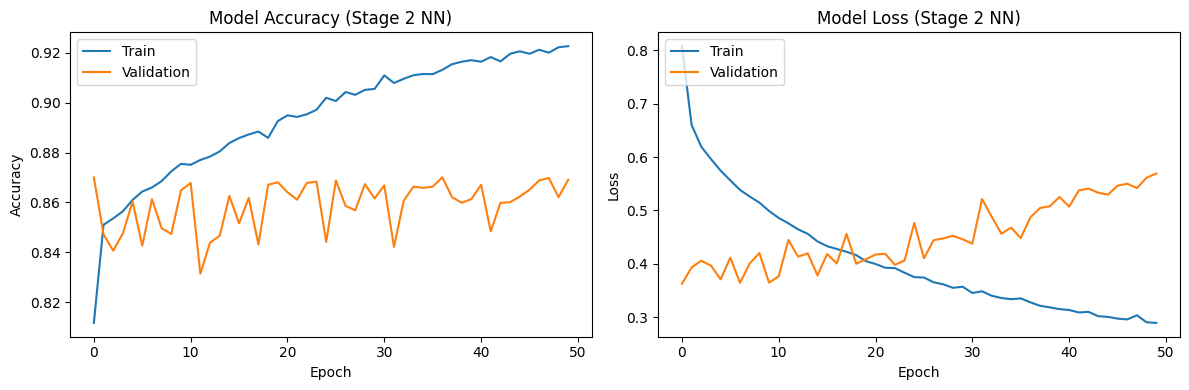

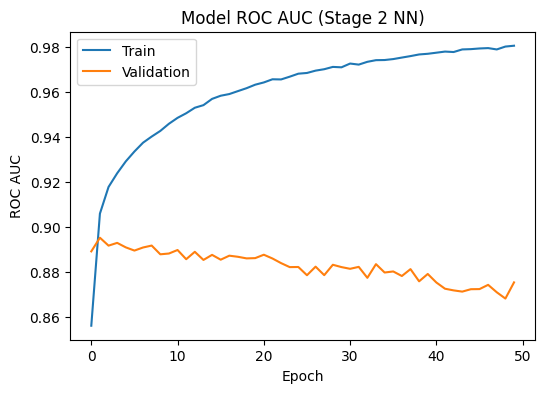


--- Evaluating Neural Network Model on Stage 2 Test Set (Initial NN) ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predictions made on Stage 2 test set.

Accuracy: 0.8645
Precision (for class 1 - Dropout): 0.5332
Recall (for class 1 - Dropout): 0.7696
ROC AUC Score: 0.8736

Classification Report (Stage 2 - Initial NN):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.96      0.88      0.92      4261
  Class 1 (Dropout)       0.53      0.77      0.63       751

           accuracy                           0.86      5012
          macro avg       0.74      0.83      0.77      5012
       weighted avg       0.89      0.86      0.87      5012


Confusion Matrix (Stage 2 - Initial NN):
[[3755  506]
 [ 173  578]]


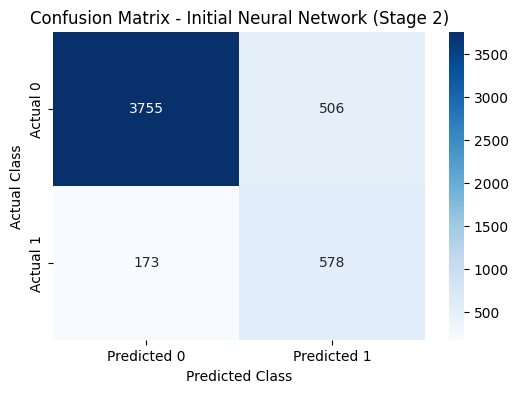

In [103]:
# --- Cell S2.14: Neural Network (Stage 2) - Build, Train, and Evaluate ---
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt # Ensure plt is imported
import seaborn as sns # Ensure seaborn is imported
import numpy as np # Ensure numpy is imported

if 'X_train_s2_scaled' in locals() and 'y_train_s2' in locals() and 'X_test_s2_scaled' in locals() and 'y_test_s2' in locals():
    print("--- Neural Network Model (Stage 2) - Initial Build, Train, and Evaluate ---")

    # Define class weights for Stage 2 training data
    count_class_0_train_s2 = np.sum(y_train_s2 == 0)
    count_class_1_train_s2 = np.sum(y_train_s2 == 1)

    if count_class_1_train_s2 > 0:
        weight_for_1_s2 = count_class_0_train_s2 / count_class_1_train_s2
    else:
        weight_for_1_s2 = 1

    class_weights_s2 = {0: 1, 1: weight_for_1_s2}
    print(f"Calculated class weights for Stage 2 Neural Network: {class_weights_s2}")

    # 1. Define the Keras Sequential model architecture (same initial as Stage 1)
    nn_model_s2 = Sequential()
    nn_model_s2.add(Dense(units=128, activation='relu', input_dim=X_train_s2_scaled.shape[1]))
    nn_model_s2.add(Dense(units=64, activation='relu'))
    nn_model_s2.add(Dense(units=1, activation='sigmoid'))

    print("\nNeural Network model (Stage 2) defined:")
    nn_model_s2.summary()

    # 2. Compile the model
    nn_model_s2.compile(optimizer='adam',
                        loss='binary_crossentropy',
                        metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')])
    print("\nNeural Network model (Stage 2) compiled.")

    # 3. Train the model
    print("\nTraining the Neural Network model (Stage 2)...")
    history_s2 = nn_model_s2.fit(
        X_train_s2_scaled,
        y_train_s2,
        epochs=50, # Using 50 epochs as in Stage 1 initial NN
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weights_s2,
        verbose=1
    )
    print("Model training complete.")

    # 4. Plot training & validation loss and accuracy curves
    print("\n--- Plotting Training History (Stage 2 NN) ---")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    if 'accuracy' in history_s2.history: plt.plot(history_s2.history['accuracy'])
    if 'val_accuracy' in history_s2.history: plt.plot(history_s2.history['val_accuracy'])
    plt.title('Model Accuracy (Stage 2 NN)')
    plt.ylabel('Accuracy'); plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    if 'loss' in history_s2.history: plt.plot(history_s2.history['loss'])
    if 'val_loss' in history_s2.history: plt.plot(history_s2.history['val_loss'])
    plt.title('Model Loss (Stage 2 NN)')
    plt.ylabel('Loss'); plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.tight_layout(); plt.show()

    if 'roc_auc' in history_s2.history and 'val_roc_auc' in history_s2.history:
        plt.figure(figsize=(6,4))
        plt.plot(history_s2.history['roc_auc'])
        plt.plot(history_s2.history['val_roc_auc'])
        plt.title('Model ROC AUC (Stage 2 NN)')
        plt.ylabel('ROC AUC'); plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left'); plt.show()

    # 5. Evaluate the model on the Stage 2 test set
    print("\n--- Evaluating Neural Network Model on Stage 2 Test Set (Initial NN) ---")
    y_pred_proba_nn_s2 = nn_model_s2.predict(X_test_s2_scaled).ravel()
    y_pred_nn_s2 = (y_pred_proba_nn_s2 > 0.5).astype(int)
    print("Predictions made on Stage 2 test set.")

    accuracy_nn_s2 = accuracy_score(y_test_s2, y_pred_nn_s2)
    precision_nn_s2 = precision_score(y_test_s2, y_pred_nn_s2)
    recall_nn_s2 = recall_score(y_test_s2, y_pred_nn_s2)
    roc_auc_nn_s2 = roc_auc_score(y_test_s2, y_pred_proba_nn_s2)

    print(f"\nAccuracy: {accuracy_nn_s2:.4f}")
    print(f"Precision (for class 1 - Dropout): {precision_nn_s2:.4f}")
    print(f"Recall (for class 1 - Dropout): {recall_nn_s2:.4f}")
    print(f"ROC AUC Score: {roc_auc_nn_s2:.4f}")

    print("\nClassification Report (Stage 2 - Initial NN):")
    print(classification_report(y_test_s2, y_pred_nn_s2, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Stage 2 - Initial NN):")
    cm_nn_s2 = confusion_matrix(y_test_s2, y_pred_nn_s2)
    print(cm_nn_s2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_nn_s2, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Initial Neural Network (Stage 2)')
    plt.ylabel('Actual Class'); plt.xlabel('Predicted Class')
    plt.show()
else:
    print("ERROR: Scaled Stage 2 training/testing data not found. Please ensure Cell S2.13 ran correctly.")

--- XGBoost Hyperparameter Tuning (Stage 2 Data) ---
Using scale_pos_weight for Stage 2: 5.68

Parameter grid for XGBoost tuning (Stage 2):
{'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7], 'n_estimators': [100, 200, 300]}

Starting GridSearchCV for XGBoost (Stage 2)... This may take some time.
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:46:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV fitting complete.

--- Best Hyperparameters Found for XGBoost (Stage 2) ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best ROC AUC Score from GridSearchCV: 0.9107

Best XGBoost model (Stage 2) has been extracted.

--- Evaluating Tuned XGBoost Model on Stage 2 Test Set ---
Accuracy (Tuned XGBoost S2): 0.8713
Precision (Tuned XGBoost S2 - for class 1): 0.5472
Recall (Tuned XGBoost S2 - for class 1): 0.8189
ROC AUC Score (Tuned XGBoost S2): 0.9195

Classification Report (Tuned XGBoost S2 Model):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.97      0.88      0.92      4261
  Class 1 (Dropout)       0.55      0.82      0.66       751

           accuracy                           0.87      5012
          macro avg       0.76      0.85      0.79      5012
       weighted avg       0.90      0.87      0.88      5012


Confusion Matrix (Tuned XGBoost S2 Model):
[[3752  509]
 [ 136  615]]


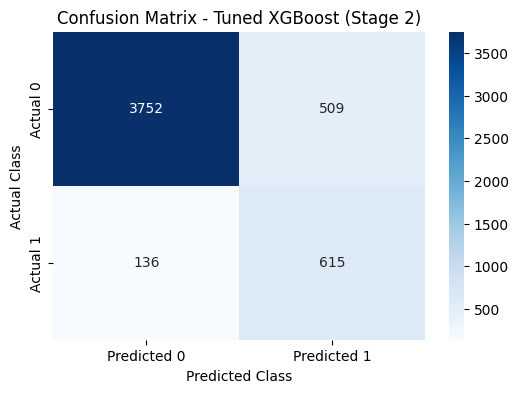


Rubric Reminder: For your report, comment on whether tuning significantly improved performance for XGBoost on Stage 2 data compared to the initial XGBoost on Stage 2 data.


In [104]:
# --- Cell S2.15: XGBoost Hyperparameter Tuning (Stage 2 Data) ---
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

if 'X_train_s2' in locals() and 'y_train_s2' in locals() and 'X_test_s2' in locals() and 'y_test_s2' in locals():
    print("--- XGBoost Hyperparameter Tuning (Stage 2 Data) ---")

    # Use scale_pos_weight calculated for Stage 2
    count_negative_class_s2 = y_train_s2.value_counts()[0]
    count_positive_class_s2 = y_train_s2.value_counts()[1]
    scale_pos_weight_value_s2 = count_negative_class_s2 / count_positive_class_s2 if count_positive_class_s2 > 0 else 1
    print(f"Using scale_pos_weight for Stage 2: {scale_pos_weight_value_s2:.2f}")

    # Define the parameter grid (same as Stage 1 for consistency, can be adjusted)
    param_grid_s2 = {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'n_estimators': [100, 200, 300]
    }
    print(f"\nParameter grid for XGBoost tuning (Stage 2):\n{param_grid_s2}")

    xgb_estimator_s2 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value_s2
    )

    grid_search_xgb_s2 = GridSearchCV(
        estimator=xgb_estimator_s2,
        param_grid=param_grid_s2,
        scoring='roc_auc',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    print("\nStarting GridSearchCV for XGBoost (Stage 2)... This may take some time.")
    grid_search_xgb_s2.fit(X_train_s2, y_train_s2)
    print("GridSearchCV fitting complete.")

    print("\n--- Best Hyperparameters Found for XGBoost (Stage 2) ---")
    print(f"Best Parameters: {grid_search_xgb_s2.best_params_}")
    print(f"Best ROC AUC Score from GridSearchCV: {grid_search_xgb_s2.best_score_:.4f}")

    best_xgb_model_s2 = grid_search_xgb_s2.best_estimator_
    print("\nBest XGBoost model (Stage 2) has been extracted.")

    print("\n--- Evaluating Tuned XGBoost Model on Stage 2 Test Set ---")
    y_pred_tuned_xgb_s2 = best_xgb_model_s2.predict(X_test_s2)
    y_pred_proba_tuned_xgb_s2 = best_xgb_model_s2.predict_proba(X_test_s2)[:, 1]

    accuracy_tuned_xgb_s2 = accuracy_score(y_test_s2, y_pred_tuned_xgb_s2)
    precision_tuned_xgb_s2 = precision_score(y_test_s2, y_pred_tuned_xgb_s2)
    recall_tuned_xgb_s2 = recall_score(y_test_s2, y_pred_tuned_xgb_s2)
    roc_auc_tuned_xgb_s2 = roc_auc_score(y_test_s2, y_pred_proba_tuned_xgb_s2)

    print(f"Accuracy (Tuned XGBoost S2): {accuracy_tuned_xgb_s2:.4f}")
    print(f"Precision (Tuned XGBoost S2 - for class 1): {precision_tuned_xgb_s2:.4f}")
    print(f"Recall (Tuned XGBoost S2 - for class 1): {recall_tuned_xgb_s2:.4f}")
    print(f"ROC AUC Score (Tuned XGBoost S2): {roc_auc_tuned_xgb_s2:.4f}")

    print("\nClassification Report (Tuned XGBoost S2 Model):")
    print(classification_report(y_test_s2, y_pred_tuned_xgb_s2, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Tuned XGBoost S2 Model):")
    cm_tuned_xgb_s2 = confusion_matrix(y_test_s2, y_pred_tuned_xgb_s2)
    print(cm_tuned_xgb_s2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_tuned_xgb_s2, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Tuned XGBoost (Stage 2)')
    plt.ylabel('Actual Class'); plt.xlabel('Predicted Class')
    plt.show()

    print("\nRubric Reminder: For your report, comment on whether tuning significantly improved performance for XGBoost on Stage 2 data compared to the initial XGBoost on Stage 2 data.")
else:
    print("ERROR: Stage 2 training/testing data not found. Please ensure Cell S2.11 (data splitting for Stage 2) ran correctly.")


Best Parameters Found by GridSearchCV: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best ROC AUC Score (from GridSearchCV on training data): 0.9107
And its performance on the Stage 2 Test Set:

Accuracy: 0.8713
Precision (for Dropout class 1): 0.5472
Recall (for Dropout class 1): 0.8189
ROC AUC Score: 0.9195
Comparison with the Initial XGBoost Model on Stage 2 Data (from Cell S2.12):

Let's compare to see if tuning significantly improved performance:

Metric	Initial XGBoost (S2)	Tuned XGBoost (S2)	Change
Accuracy	0.8777	0.8713	Slightly Lower
Precision (Class 1)	0.5641	0.5472	Slightly Lower
Recall (Class 1)	0.8083	0.8189	Slightly Higher
ROC AUC	0.9206	0.9195	Slightly Lower


Analysis of Tuning Impact for XGBoost (Stage 2):

In this case, hyperparameter tuning for the XGBoost model on the Stage 2 data resulted in a very slight increase in Recall for the dropout class, but the other metrics (Accuracy, Precision, ROC AUC) are marginally lower or very similar to the initial model (which already used scale_pos_weight). This suggests that the default parameters (with scale_pos_weight) were already quite effective for this dataset, or the chosen parameter grid for tuning didn't uncover a combination that provides a significant uplift across all key metrics. The change in n_estimators from 100 (common default often used implicitly if not specified in a very basic model) to 200 is the main difference in the tuned parameters compared to very basic defaults.



Trial 10 Complete [00h 00m 31s]
val_roc_auc: 0.8965640068054199

Best val_roc_auc So Far: 0.9068098068237305
Total elapsed time: 00h 04m 34s
Keras Tuner search complete for Stage 2 NN.

--- Best Hyperparameters Found for Neural Network (Stage 2) ---
Neurons Layer 1: 160
Activation Layer 1: tanh
Neurons Layer 2: 32
Activation Layer 2: tanh
Optimizer: rmsprop
RMSprop Learning Rate: 0.00195

Best Neural Network model (Stage 2) has been extracted from Keras Tuner.

--- Evaluating Tuned Neural Network Model on Stage 2 Test Set ---
 42/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy (Tuned NN S2): 0.8687
Precision (Tuned NN S2 - for class 1): 0.5429
Recall (Tuned NN S2 - for class 1): 0.7843
ROC AUC Score (Tuned NN S2): 0.8969

Classification Report (Tuned NN S2 Model):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.96      0.88      0.92      4261
  Class 1 (Dropout)       0.54      0.78      0.64       751

           accuracy                           0.87      5012
          macro avg       0.75      0.83      0.78      5012
       weighted avg       0.90      0.87      0.88      5012


Confusion Matrix (Tuned NN S2 Model):
[[3765  496]
 [ 162  589]]


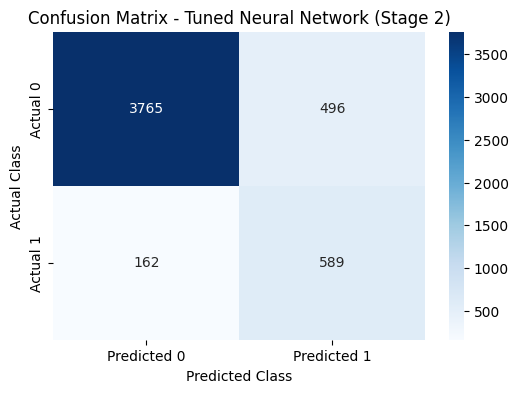


Rubric Reminder: For your report, comment on whether tuning significantly improved performance for the Neural Network on Stage 2 data compared to the initial NN on Stage 2 data (Cell S2.14).


In [105]:
# --- Cell S2.16: Neural Network Hyperparameter Tuning (Stage 2 Data with Keras Tuner) ---
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
import keras_tuner as kt # Keras Tuner import
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_train_s2_scaled, y_train_s2, X_test_s2_scaled, y_test_s2 are available from previous cells S2.11 & S2.13

if 'X_train_s2_scaled' in locals() and 'y_train_s2' in locals() and 'X_test_s2_scaled' in locals() and 'y_test_s2' in locals():
    print("--- Neural Network Hyperparameter Tuning with Keras Tuner (Stage 2 Data) ---")

    # Define class weights for Stage 2 training data
    count_class_0_train_s2 = np.sum(y_train_s2 == 0)
    count_class_1_train_s2 = np.sum(y_train_s2 == 1)
    weight_for_1_s2 = count_class_0_train_s2 / count_class_1_train_s2 if count_class_1_train_s2 > 0 else 1
    class_weights_dict_s2 = {0: 1.0, 1: float(weight_for_1_s2)}
    print(f"Using class weights for Stage 2 NN: {class_weights_dict_s2}")

    # 1. Define the model-building function for Keras Tuner (specific for Stage 2 input_dim)
    def build_model_for_tuner_s2(hp): # hp is the HyperParameters object
        model = keras.Sequential()
        model.add(Dense(
            units=hp.Int('neurons1', min_value=32, max_value=256, step=32),
            activation=hp.Choice('activation1', values=['relu', 'tanh']),
            input_dim=X_train_s2_scaled.shape[1] # Use Stage 2 scaled data input dimension
        ))
        model.add(Dense(
            units=hp.Int('neurons2', min_value=32, max_value=128, step=32),
            activation=hp.Choice('activation2', values=['relu', 'tanh'])
        ))
        model.add(Dense(units=1, activation='sigmoid'))

        optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop'])
        if optimizer_choice == 'adam':
            optimizer = keras.optimizers.Adam(hp.Float('lr_adam', min_value=1e-4, max_value=1e-2, sampling='log'))
        else:
            optimizer = keras.optimizers.RMSprop(hp.Float('lr_rmsprop', min_value=1e-4, max_value=1e-2, sampling='log'))

        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
        )
        return model

    # 2. Instantiate the Tuner
    tuner_s2 = kt.RandomSearch(
        build_model_for_tuner_s2,
        objective=kt.Objective('val_roc_auc', direction='max'),
        max_trials=10,  # Number of hyperparameter combinations to test
        executions_per_trial=1,
        directory='keras_tuner_dir_s2', # Use a different directory for Stage 2 results
        project_name='student_dropout_nn_tuning_s2'
    )

    print("\nStarting Keras Tuner search for Stage 2 NN... This may take some time.")
    # 3. Run the hyperparameter search
    tuner_s2.search(
        X_train_s2_scaled, y_train_s2,
        epochs=50, # Max epochs for each trial
        validation_split=0.2,
        class_weight=class_weights_dict_s2,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)]
    )
    print("Keras Tuner search complete for Stage 2 NN.")

    # 4. Get the best hyperparameters and the best model
    best_hps_s2 = tuner_s2.get_best_hyperparameters(num_trials=1)[0]
    print("\n--- Best Hyperparameters Found for Neural Network (Stage 2) ---")
    print(f"Neurons Layer 1: {best_hps_s2.get('neurons1')}")
    print(f"Activation Layer 1: {best_hps_s2.get('activation1')}")
    print(f"Neurons Layer 2: {best_hps_s2.get('neurons2')}")
    print(f"Activation Layer 2: {best_hps_s2.get('activation2')}")
    print(f"Optimizer: {best_hps_s2.get('optimizer')}")
    if best_hps_s2.get('optimizer') == 'adam':
        print(f"Adam Learning Rate: {best_hps_s2.get('lr_adam'):.5f}") # Increased precision for LR
    else:
        print(f"RMSprop Learning Rate: {best_hps_s2.get('lr_rmsprop'):.5f}") # Increased precision for LR

    best_nn_model_s2 = tuner_s2.get_best_models(num_models=1)[0]
    print("\nBest Neural Network model (Stage 2) has been extracted from Keras Tuner.")

    # 5. Evaluate the tuned Neural Network model on the Stage 2 test set
    print("\n--- Evaluating Tuned Neural Network Model on Stage 2 Test Set ---")
    y_pred_proba_tuned_nn_s2 = best_nn_model_s2.predict(X_test_s2_scaled).ravel()
    y_pred_tuned_nn_s2 = (y_pred_proba_tuned_nn_s2 > 0.5).astype(int)

    accuracy_tuned_nn_s2 = accuracy_score(y_test_s2, y_pred_tuned_nn_s2)
    precision_tuned_nn_s2 = precision_score(y_test_s2, y_pred_tuned_nn_s2)
    recall_tuned_nn_s2 = recall_score(y_test_s2, y_pred_tuned_nn_s2)
    roc_auc_tuned_nn_s2 = roc_auc_score(y_test_s2, y_pred_proba_tuned_nn_s2)

    print(f"Accuracy (Tuned NN S2): {accuracy_tuned_nn_s2:.4f}")
    print(f"Precision (Tuned NN S2 - for class 1): {precision_tuned_nn_s2:.4f}")
    print(f"Recall (Tuned NN S2 - for class 1): {recall_tuned_nn_s2:.4f}")
    print(f"ROC AUC Score (Tuned NN S2): {roc_auc_tuned_nn_s2:.4f}")

    print("\nClassification Report (Tuned NN S2 Model):")
    print(classification_report(y_test_s2, y_pred_tuned_nn_s2, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Tuned NN S2 Model):")
    cm_tuned_nn_s2 = confusion_matrix(y_test_s2, y_pred_tuned_nn_s2)
    print(cm_tuned_nn_s2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_tuned_nn_s2, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Tuned Neural Network (Stage 2)')
    plt.ylabel('Actual Class'); plt.xlabel('Predicted Class'); plt.show()

    print("\nRubric Reminder: For your report, comment on whether tuning significantly improved performance for the Neural Network on Stage 2 data compared to the initial NN on Stage 2 data (Cell S2.14).")
else:
    print("ERROR: Scaled Stage 2 training/testing data not found. Please ensure Cell S2.13 ran correctly.")

Best Hyperparameters Found by Keras Tuner:
Neurons Layer 1: 160
Activation Layer 1: tanh
Neurons Layer 2: 32
Activation Layer 2: tanh
Optimizer: rmsprop
RMSprop Learning Rate: 0.00195
Best val_roc_auc during tuning: 0.9068
And its performance on the Stage 2 Test Set:

Accuracy: 0.8687
Precision (for Dropout class 1): 0.5429
Recall (for Dropout class 1): 0.7843
ROC AUC Score: 0.8969
Comparison with the Initial Neural Network on Stage 2 Data (from Cell S2.14):

Let's see if tuning significantly improved performance for the Neural Network on Stage 2 data:

Metric	Initial NN (S2)	Tuned NN (S2)	Change
Accuracy	0.8645	0.8687	Slight Improve
Precision (Class 1)	0.5332	0.5429	Slight Improve
Recall (Class 1)	0.7696	0.7843	Slight Improve
ROC AUC	0.8736	0.8969	Improved

Analysis of Tuning Impact for Neural Network (Stage 2):
Hyperparameter tuning has provided a good improvement for the Neural Network on Stage 2 data. All key metrics saw an increase, with a notable improvement in the ROC AUC score (from 0.8736 to 0.8969). This indicates that the tuning process found a more optimal set of hyperparameters (architecture, optimizer, learning rate) for this specific dataset.

In [106]:
# --- Cell S2.17: Overall Model Comparison (Stage 1 vs. Stage 2 Tuned Models) ---
import pandas as pd

# Data for the comparison table
# Please verify these values against your actual outputs from the respective cells.
comparison_data = {
    'Model Type': ['Tuned XGBoost', 'Tuned Neural Network', 'Tuned XGBoost', 'Tuned Neural Network'],
    'Data Stage': ['Stage 1', 'Stage 1', 'Stage 2', 'Stage 2'],
    'Accuracy': [0.8514, 0.8488, 0.8713, 0.8687],
    'Precision (Class 1 - Dropout)': [0.5026, 0.4970, 0.5472, 0.5429],
    'Recall (Class 1 - Dropout)': [0.7696, 0.7617, 0.8189, 0.7843],
    'ROC AUC': [0.8880, 0.8714, 0.9195, 0.8969]
}

comparison_full_df = pd.DataFrame(comparison_data)

print("--- Overall Comparison of Tuned Model Performance (Stage 1 vs. Stage 2) ---")
display(comparison_full_df)



--- Overall Comparison of Tuned Model Performance (Stage 1 vs. Stage 2) ---


,Model Type,Data Stage,Accuracy,Precision (Class 1 - Dropout),Recall (Class 1 - Dropout),ROC AUC
0,Tuned XGBoost,Stage 1,0.8514,0.5026,0.7696,0.8880
1,Tuned Neural Network,Stage 1,0.8488,0.4970,0.7617,0.8714
2,Tuned XGBoost,Stage 2,0.8713,0.5472,0.8189,0.9195
3,Tuned Neural Network,Stage 2,0.8687,0.5429,0.7843,0.8969



Key Observations from this comparison for your report:
- How does XGBoost performance on Stage 2 data compare to its performance on Stage 1 data?
- How does Neural Network performance on Stage 2 data compare to its performance on Stage 1 data?
- Which model performed best overall on Stage 1 data? Which performed best on Stage 2 data?
- Did the inclusion of new data/features in Stage 2 (e.g., absence counts) lead to improved model performance for both model types?

Rubric Reminder: For your report, you need to:
1. Compare these results in detail.
2. Explain why the results are different (e.g., impact of new features in Stage 2 data, model suitability).




Overall Comparison of Tuned Model Performance (Stage 1 vs. Stage 2):

Model Type	Data Stage	Accuracy	Precision (Class 1 - Dropout)	Recall (Class 1 - Dropout)	ROC AUC
Tuned XGBoost	Stage 1	0.8514	0.5026	0.7696	0.8880
Tuned Neural Network	Stage 1	0.8488	0.4970	0.7617	0.8714
Tuned XGBoost	Stage 2	0.8713	0.5472	0.8189	0.9195
Tuned Neural Network	Stage 2	0.8687	0.5429	0.7843	0.8969

This table clearly shows that:

Both models (XGBoost and Neural Network) performed better on Stage 2 data compared to Stage 1 data across most metrics, especially ROC AUC and Recall for the dropout class. This suggests the Stage 2 data (which includes the new absence count features) is more informative.
On Stage 2 data, the Tuned XGBoost model (ROC AUC 0.9195) slightly outperforms the Tuned Neural Network (ROC AUC 0.8969), similar to the pattern seen in Stage 1.
You now have all the quantitative results needed for the rubric item "Compare the results of the XGBOOST and Neural network models on the Stage 2 dataset Vs the Stage 1 dataset." The key observation prompts and the reminder about explaining why these results are different will guide you in writing that section of your report.

This concludes the modeling, tuning, and comparison tasks for Stage 2!



# Stage 3 data

In [ ]:
# File URL
file_url = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [107]:
# --- Cell S3.1: Load Stage 3 Dataset ---
import pandas as pd # Ensure pandas is imported

file_url_stage3 = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

try:
    df_stage3_raw = pd.read_csv(file_url_stage3)
    print("Stage 3 data loaded successfully!")
    print(f"Dataset shape: {df_stage3_raw.shape}")
    # Create a working copy for pre-processing
    df_stage3_processed = df_stage3_raw.copy()
except Exception as e:
    print(f"Error loading Stage 3 data: {e}")
    print("You might need to download the file manually or use a different method to load it from Google Drive.")
    # df_stage3_processed = None # Ensure it's None if loading fails

Stage 3 data loaded successfully!
Dataset shape: (25059, 21)


In [108]:
# --- Cell S3.2: Initial Data Inspection (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    print("First 5 rows of the Stage 3 dataset:")
    display(df_stage3_processed.head())

    print("\nStage 3 DataFrame Info:")
    df_stage3_processed.info()

    print("\nStage 3 Descriptive Statistics:")
    display(df_stage3_processed.describe(include='all'))

    # Check for any completely empty columns, if any
    # empty_cols = df_stage3_processed.columns[df_stage3_processed.isnull().all()].tolist()
    # if empty_cols:
    #    print(f"\nWarning: The following columns are completely empty: {empty_cols}")

else:
    print("Stage 3 DataFrame not loaded. Please check Cell S3.1.")

First 5 rows of the Stage 3 dataset:


,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
0,ISC_Aberdeen,2284932,Agent,Standard Agent Booking,NaN,13/01/1998,Male,Chinese,Jianye District; Jiangsu Province,Nanjing,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,Msc Econ Accounting and Investment Management,University of Aberdeen,NaN,NaN
1,ISC_Aberdeen,2399500,Agent,Standard Agent Booking,NaN,12/2/1998,Male,Chinese,NaN,Xi'an,...,Life Sciences Undergraduate Foundation Programme,False,Yes,7.0,7.0,0.0,BSc Biological Sciences,University of Aberdeen,93.0,5.0
2,ISC_Aberdeen,2424946,Agent,Standard Agent Booking,NaN,7/4/2000,Male,Chinese,NaN,Chengdu,...,Business Management and Finance International ...,False,Yes,8.0,8.0,0.0,MA Finance,University of Aberdeen,92.0,6.0
3,ISC_Aberdeen,2426583,Agent,Standard Agent Booking,NaN,18/05/1999,Male,Chinese,NaN,LIUYANG CITY ;CHANGSHA,...,Business Management and Finance International ...,True,Yes,8.0,8.0,0.0,MA Business Management,University of Aberdeen,67.0,15.0
4,ISC_Aberdeen,2434674,Agent,Standard Agent Booking,NaN,19/04/1996,Male,Chinese,NaN,Xiamen,...,Business and Law Pre-Masters,True,Yes,4.0,4.0,0.0,MSc International Business Management,University of Aberdeen,NaN,NaN



Stage 3 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 
 1   LearnerCode               25059 non-null  int64  
 2   BookingType               25059 non-null  object 
 3   LeadSource                25059 non-null  object 
 4   DiscountType              7595 non-null   object 
 5   DateofBirth               25059 non-null  object 
 6   Gender                    25059 non-null  object 
 7   Nationality               25059 non-null  object 
 8   HomeState                 8925 non-null   object 
 9   HomeCity                  21611 non-null  object 
 10  CourseLevel               25059 non-null  object 
 11  CourseName                25059 non-null  object 
 12  IsFirstIntake             25059 non-null  bool   
 13  CompletedCourse           25059 non-

,CentreName,LearnerCode,BookingType,LeadSource,DiscountType,DateofBirth,Gender,Nationality,HomeState,HomeCity,...,CourseName,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,ProgressionDegree,ProgressionUniversity,AuthorisedAbsenceCount,UnauthorisedAbsenceCount
count,25059,2.505900e+04,25059,25059,7595,25059,25059,25059,8925,21611,...,25059,25059,25059,22828.000000,22828.000000,22828.000000,24184,25059,24851.000000,24851.000000
unique,19,NaN,2,7,11,4705,2,151,2448,5881,...,172,2,2,NaN,NaN,NaN,2616,40,NaN,NaN
top,ISC_Sheffield,NaN,Agent,Standard Agent Booking,Bursary,1/1/2002,Male,Chinese,Punjab,Sylhet,...,Pre-Masters Business; Social Sciences and Huma...,False,Yes,NaN,NaN,NaN,BSc (Hons) Computer Science,University of Sheffield International College,NaN,NaN
freq,5877,NaN,21878,20284,3561,37,15655,9042,865,675,...,1682,22035,21305,NaN,NaN,NaN,998,5877,NaN,NaN
mean,NaN,2.606594e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.090328,5.582881,0.507447,NaN,NaN,15.120639,40.491892
std,NaN,8.798838e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.811116,2.361530,1.304677,NaN,NaN,28.918253,39.029384
min,NaN,2.139267e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000
25%,NaN,2.538411e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.000000,4.000000,0.000000,NaN,NaN,0.000000,12.000000
50%,NaN,2.607941e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.000000,6.000000,0.000000,NaN,NaN,1.000000,29.000000
75%,NaN,2.665460e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.000000,7.000000,0.000000,NaN,NaN,15.000000,56.000000


In [109]:
# --- Cell S3.3: Remove 'LearnerCode' column (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    learner_code_column_s3 = 'LearnerCode' # Or the exact name if different in Stage 3 data

    if learner_code_column_s3 in df_stage3_processed.columns:
        df_stage3_processed.drop(columns=[learner_code_column_s3], inplace=True)
        print(f"Column '{learner_code_column_s3}' removed successfully from Stage 3 data.")
    else:
        print(f"Column '{learner_code_column_s3}' not found in the Stage 3 dataset.")
    print(f"Shape after attempting to remove LearnerCode: {df_stage3_processed.shape}")
else:
    print("Stage 3 DataFrame not loaded.")

Column 'LearnerCode' removed successfully from Stage 3 data.
Shape after attempting to remove LearnerCode: (25059, 20)


In [110]:
# --- Cell S3.4: Convert DateofBirth to datetime objects (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    if 'DateofBirth' in df_stage3_processed.columns:
        print("Attempting to convert 'DateofBirth' to datetime for Stage 3 data...")
        # Add dayfirst=True to the line below if you get a UserWarning about date parsing,
        # and you know your dates are in DD/MM/YYYY format.
        df_stage3_processed['DateofBirth'] = pd.to_datetime(df_stage3_processed['DateofBirth'], errors='coerce')

        num_nat_s3 = df_stage3_processed['DateofBirth'].isnull().sum()
        if num_nat_s3 > 0:
            print(f"WARNING: Could not parse {num_nat_s3} entries in 'DateofBirth' (Stage 3). They have been set to NaT.")

        print("'DateofBirth' column (Stage 3) dtype after conversion attempt:", df_stage3_processed['DateofBirth'].dtype)
        print("Sample of 'DateofBirth' column (Stage 3):")
        print(df_stage3_processed[['DateofBirth']].head())
    else:
        print("'DateofBirth' column not found in Stage 3 data.")
else:
    print("Stage 3 DataFrame not loaded.")

Attempting to convert 'DateofBirth' to datetime for Stage 3 data...
'DateofBirth' column (Stage 3) dtype after conversion attempt: datetime64[ns]
Sample of 'DateofBirth' column (Stage 3):
  DateofBirth
0  1998-01-13
1  1998-02-12
2  2000-04-07
3  1999-05-18
4  1996-04-19


<ipython-input-110-67dfd19946b8>:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_stage3_processed['DateofBirth'] = pd.to_datetime(df_stage3_processed['DateofBirth'], errors='coerce')


In [112]:
# --- Cell S3.5: Feature Engineering - Create 'Age' (Stage 3) ---
from datetime import datetime # Ensure datetime is imported
import pandas as pd # Ensure pandas is imported

if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    if 'DateofBirth' in df_stage3_processed.columns and pd.api.types.is_datetime64_any_dtype(df_stage3_processed['DateofBirth']):
        print("Creating 'Age' feature for Stage 3 data...")
        today = pd.to_datetime(datetime.today().strftime('%Y-%m-%d'))
        df_stage3_processed['Age'] = (today - df_stage3_processed['DateofBirth']).dt.days // 365.25
        df_stage3_processed['Age'] = df_stage3_processed['Age'].astype(int)

        # Drop the original DateofBirth column
        df_stage3_processed.drop(columns=['DateofBirth'], inplace=True)

        print("'Age' feature created and 'DateofBirth' column dropped for Stage 3.")
        print(df_stage3_processed[['Age']].head())
        print(f"Current shape of df_stage3_processed: {df_stage3_processed.shape}")
        print(f"Current columns: {list(df_stage3_processed.columns)}")
    elif 'DateofBirth' not in df_stage3_processed.columns:
        print("ERROR: 'DateofBirth' column not found in Stage 3 df_stage3_processed. Cannot create 'Age'.")
    else: # DateofBirth is present but not datetime
        print("ERROR: 'DateofBirth' column in Stage 3 data is not in datetime format. Please ensure Cell S3.4 ran correctly.")
else:
    print("ERROR: df_stage3_processed not found. Please ensure data loading (Cell S3.1) and previous steps were successful.")

Creating 'Age' feature for Stage 3 data...
'Age' feature created and 'DateofBirth' column dropped for Stage 3.
   Age
0   27
1   27
2   25
3   26
4   29
Current shape of df_stage3_processed: (25059, 20)
Current columns: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'HomeState', 'HomeCity', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'AssessedModules', 'PassedModules', 'FailedModules', 'ProgressionDegree', 'ProgressionUniversity', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount', 'Age']


In [113]:
# --- Cell S3.6: Feature Engineering - Convert Target Variable to Binary (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    target_column_s3 = 'CompletedCourse'
    if target_column_s3 in df_stage3_processed.columns:
        print(f"Unique values in '{target_column_s3}' (Stage 3) before conversion:")
        print(df_stage3_processed[target_column_s3].value_counts(dropna=False))

        # Mapping: 'No' (dropout) -> 1, 'Yes' (completed) -> 0
        mapping_s3 = {'No': 1, 'Yes': 0}

        # Ensure all values are either 'Yes' or 'No' before mapping, or handle others if necessary
        # For simplicity, assuming only 'Yes' and 'No' exist as per your last confirmation.
        df_stage3_processed[target_column_s3] = df_stage3_processed[target_column_s3].map(mapping_s3)

        print(f"\n'{target_column_s3}' (Stage 3) after conversion to binary:")
        print(df_stage3_processed[target_column_s3].value_counts(dropna=False))
        print(f"Data type of '{target_column_s3}' after mapping: {df_stage3_processed[target_column_s3].dtype}")

        if df_stage3_processed[target_column_s3].isnull().any():
            print(f"\nWARNING: NaNs present in '{target_column_s3}' after mapping. "
                  "This means some original values were not 'Yes' or 'No', or were already NaN.")
            print(f"Number of NaNs: {df_stage3_processed[target_column_s3].isnull().sum()}")
        else:
            print(f"\nNo NaNs introduced in '{target_column_s3}' by mapping (or original NaNs handled by mapping).")
    else:
        print(f"ERROR: Target column '{target_column_s3}' is missing from Stage 3 data.")
else:
    print(f"ERROR: df_stage3_processed not found.")

Unique values in 'CompletedCourse' (Stage 3) before conversion:
CompletedCourse
Yes    21305
No      3754
Name: count, dtype: int64

'CompletedCourse' (Stage 3) after conversion to binary:
CompletedCourse
0    21305
1     3754
Name: count, dtype: int64
Data type of 'CompletedCourse' after mapping: int64

No NaNs introduced in 'CompletedCourse' by mapping (or original NaNs handled by mapping).


In [114]:
# --- Cell S3.7: Remove Columns with High Cardinality (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    high_cardinality_threshold_s3 = 200

    cols_before_s3_cell7_execution = list(df_stage3_processed.columns)

    print(f"--- High Cardinality Check (Stage 3 - Threshold: >{high_cardinality_threshold_s3} unique values) ---")
    print(f"Number of columns before this check: {len(cols_before_s3_cell7_execution)}")

    object_cols_to_drop_hc_s3 = []

    # Columns to explicitly skip from this specific cardinality check for object types
    # (target, already numeric, or boolean that will become numeric)
    # The new academic and absence columns are float64, Age is int64, IsFirstIntake is bool, CompletedCourse is int64.
    skip_cols_for_object_cardinality_check = [
        'CompletedCourse', 'Age', 'IsFirstIntake',
        'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount',
        'AssessedModules', 'PassedModules', 'FailedModules'
    ]

    for col in list(df_stage3_processed.columns):
        if col in skip_cols_for_object_cardinality_check:
            continue

        if df_stage3_processed[col].dtype == 'object': # Focus on object columns
            num_unique = df_stage3_processed[col].nunique()
            if num_unique > high_cardinality_threshold_s3:
                print(f"INFO: Object column '{col}' (dtype: {df_stage3_processed[col].dtype}) has {num_unique} unique values. Marked for automatic removal.")
                object_cols_to_drop_hc_s3.append(col)

    if object_cols_to_drop_hc_s3:
        df_stage3_processed.drop(columns=object_cols_to_drop_hc_s3, inplace=True)
        print(f"\nACTION: Automatically removed high cardinality OBJECT columns: {object_cols_to_drop_hc_s3}")
    else:
        print("\nINFO: No OBJECT columns found exceeding the high cardinality threshold for automatic removal.")

    cols_after_s3_cell7_execution = list(df_stage3_processed.columns)
    dropped_in_this_run_s3_cell7 = [col for col in cols_before_s3_cell7_execution if col not in cols_after_s3_cell7_execution]

    print(f"\n--- Summary of Cardinality Check (Stage 3 - Cell S3.7) ---")
    if dropped_in_this_run_s3_cell7:
        print(f"Columns dropped in THIS run of Cell S3.7: {dropped_in_this_run_s3_cell7} (Total: {len(dropped_in_this_run_s3_cell7)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell S3.7.")

    print(f"Current shape of df_stage3_processed: {df_stage3_processed.shape}")
    print(f"Current columns in df_stage3_processed: {list(df_stage3_processed.columns)}")
else:
    print("ERROR: df_stage3_processed not found. Please ensure previous Stage 3 cells ran correctly.")

--- High Cardinality Check (Stage 3 - Threshold: >200 unique values) ---
Number of columns before this check: 20
INFO: Object column 'HomeState' (dtype: object) has 2448 unique values. Marked for automatic removal.
INFO: Object column 'HomeCity' (dtype: object) has 5881 unique values. Marked for automatic removal.
INFO: Object column 'ProgressionDegree' (dtype: object) has 2616 unique values. Marked for automatic removal.

ACTION: Automatically removed high cardinality OBJECT columns: ['HomeState', 'HomeCity', 'ProgressionDegree']

--- Summary of Cardinality Check (Stage 3 - Cell S3.7) ---
Columns dropped in THIS run of Cell S3.7: ['HomeState', 'HomeCity', 'ProgressionDegree'] (Total: 3)
Current shape of df_stage3_processed: (25059, 17)
Current columns in df_stage3_processed: ['CentreName', 'BookingType', 'LeadSource', 'DiscountType', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'AssessedModules', 'PassedModules', 'FailedModules', 'Progressi

In [115]:
# --- Cell S3.8: Remove Columns with >50% Missing Data (Stage 3) ---
if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    cols_before_s3_cell8_execution = list(df_stage3_processed.columns)
    print(f"\n\n--- Missing Data Check for Column Removal (Stage 3 - Threshold: >50% missing) ---")
    print(f"Number of columns before this check: {len(cols_before_s3_cell8_execution)}")

    missing_data_threshold_s3 = 0.50 # 50%
    columns_to_drop_missing_s3 = []

    missing_percentages_s3 = df_stage3_processed.isnull().sum() / len(df_stage3_processed)
    print("\nPercentage of missing values per column (Stage 3 - showing only those with missing values):")
    current_missing_summary_s3 = missing_percentages_s3[missing_percentages_s3 > 0].sort_values(ascending=False)
    if not current_missing_summary_s3.empty:
        print(current_missing_summary_s3)
    else:
        print("No columns currently have any missing values.")

    for col, percentage in missing_percentages_s3.items():
        if percentage > missing_data_threshold_s3:
            if col == 'CompletedCourse': # Don't drop the target
                 print(f"INFO: Target column '{col}' has {percentage*100:.2f}% missing values, but will be skipped for removal.")
                 continue
            print(f"INFO: Column '{col}' has {percentage*100:.2f}% missing values. Marking for removal.")
            columns_to_drop_missing_s3.append(col)

    if columns_to_drop_missing_s3:
        df_stage3_processed.drop(columns=columns_to_drop_missing_s3, inplace=True)
        print(f"\nACTION: Removed columns with >{missing_data_threshold_s3*100}% missing data: {columns_to_drop_missing_s3}")
    else:
        print("\nINFO: No columns found exceeding the missing data threshold for removal.")

    cols_after_s3_cell8_execution = list(df_stage3_processed.columns)
    dropped_in_this_run_s3_cell8 = [col for col in cols_before_s3_cell8_execution if col not in cols_after_s3_cell8_execution]

    print(f"\n--- Summary of Missing Data Column Removal (Stage 3 - Cell S3.8) ---")
    if dropped_in_this_run_s3_cell8:
        print(f"Columns dropped in THIS run of Cell S3.8: {dropped_in_this_run_s3_cell8} (Total: {len(dropped_in_this_run_s3_cell8)})")
    else:
        print("No columns were dropped by the automatic logic in THIS run of Cell S3.8.")

    print(f"Current shape of df_stage3_processed: {df_stage3_processed.shape}")
    print(f"Current columns in df_stage3_processed: {list(df_stage3_processed.columns)}")

    print("\nMissing values summary after column removals (Stage 3 - Cell S3.8):")
    remaining_missing_s3 = df_stage3_processed.isnull().sum()
    final_missing_summary_s3 = remaining_missing_s3[remaining_missing_s3 > 0].sort_values(ascending=False)
    if not final_missing_summary_s3.empty:
        print(final_missing_summary_s3)
    else:
        print("No missing values remaining in the dataset (or all columns with missing data were below the 50% threshold or were the target).")
else:
    print("ERROR: df_stage3_processed not found. Please ensure previous Stage 3 cells ran correctly.")



--- Missing Data Check for Column Removal (Stage 3 - Threshold: >50% missing) ---
Number of columns before this check: 17

Percentage of missing values per column (Stage 3 - showing only those with missing values):
DiscountType                0.696915
AssessedModules             0.089030
PassedModules               0.089030
FailedModules               0.089030
AuthorisedAbsenceCount      0.008300
UnauthorisedAbsenceCount    0.008300
dtype: float64
INFO: Column 'DiscountType' has 69.69% missing values. Marking for removal.

ACTION: Removed columns with >50.0% missing data: ['DiscountType']

--- Summary of Missing Data Column Removal (Stage 3 - Cell S3.8) ---
Columns dropped in THIS run of Cell S3.8: ['DiscountType'] (Total: 1)
Current shape of df_stage3_processed: (25059, 16)
Current columns in df_stage3_processed: ['CentreName', 'BookingType', 'LeadSource', 'Gender', 'Nationality', 'CourseLevel', 'CourseName', 'IsFirstIntake', 'CompletedCourse', 'AssessedModules', 'PassedModules', 'F

In [116]:
# --- Cell S3.9: Handle Remaining Missing Values (Stage 3 Guideline) ---
from sklearn.impute import SimpleImputer
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    print("--- Handling Remaining Missing Values (Stage 3) ---")

    # Calculate the number of rows with at least one missing value
    rows_with_missing_values = df_stage3_processed[df_stage3_processed.isnull().any(axis=1)]
    num_rows_with_missing = len(rows_with_missing_values)
    total_rows = len(df_stage3_processed)
    percentage_rows_with_missing = (num_rows_with_missing / total_rows) * 100

    print(f"Total rows in DataFrame: {total_rows}")
    print(f"Number of rows with at least one missing value: {num_rows_with_missing}")
    print(f"Percentage of rows with at least one missing value: {percentage_rows_with_missing:.2f}%")

    # Stage 3 Guideline: Remove rows if <2% of rows have missing values, otherwise impute.
    if percentage_rows_with_missing > 0 and percentage_rows_with_missing < 2.0:
        print("\nAction: Percentage of rows with missing values is < 2%. Removing these rows.")
        df_stage3_processed.dropna(inplace=True)
        print(f"Shape after removing rows with missing values: {df_stage3_processed.shape}")
    elif num_rows_with_missing > 0: # Impute if >= 2% or if there are any missing rows not caught by the <2% drop
        print("\nAction: Percentage of rows with missing values is >= 2% or no rows were dropped. Proceeding with imputation.")

        # Identify columns that still have missing values
        cols_with_missing_values = df_stage3_processed.columns[df_stage3_processed.isnull().any()].tolist()

        numerical_cols_to_impute_s3 = []
        # categorical_cols_to_impute_s3 = [] # In case any object types had minor missing data

        for col in cols_with_missing_values:
            if df_stage3_processed[col].dtype in ['float64', 'int64']:
                numerical_cols_to_impute_s3.append(col)
            # elif df_stage3_processed[col].dtype == 'object':
            #     categorical_cols_to_impute_s3.append(col)

        if numerical_cols_to_impute_s3:
            print(f"Numerical columns to impute with median: {numerical_cols_to_impute_s3}")
            numerical_imputer_s3 = SimpleImputer(strategy='median')
            df_stage3_processed[numerical_cols_to_impute_s3] = numerical_imputer_s3.fit_transform(df_stage3_processed[numerical_cols_to_impute_s3])
            print("Median imputation applied to numerical columns.")
        else:
            print("No numerical columns with missing values were identified for imputation at this step.")

        # Add categorical imputation here if needed, though current missing columns are numerical
        # if categorical_cols_to_impute_s3:
        #     print(f"Categorical columns to impute with mode: {categorical_cols_to_impute_s3}")
        #     categorical_imputer_s3 = SimpleImputer(strategy='most_frequent')
        #     for col in categorical_cols_to_impute_s3:
        #         df_stage3_processed[col] = categorical_imputer_s3.fit_transform(df_stage3_processed[[col]])
        #     print("Mode imputation applied to categorical columns.")
        # else:
        #     print("No categorical columns found with missing values for imputation at this step.")
    else:
        print("\nNo rows with missing values found to handle.")

    print("\n--- Missing Values Summary After Handling (Stage 3 - Cell S3.9) ---")
    final_remaining_missing_s3 = df_stage3_processed.isnull().sum()
    missing_in_cols_final_s3 = final_remaining_missing_s3[final_remaining_missing_s3 > 0]

    if not missing_in_cols_final_s3.empty:
        print("Columns STILL having missing values (this should not happen if logic is correct):")
        print(missing_in_cols_final_s3)
    else:
        print("No missing values remaining in the dataset after handling.")

    print(f"\nCurrent shape of df_stage3_processed: {df_stage3_processed.shape}")
    print("\nDataFrame info after handling missing values:")
    df_stage3_processed.info()
else:
    print("ERROR: df_stage3_processed not found. Please ensure previous Stage 3 cells ran correctly.")

--- Handling Remaining Missing Values (Stage 3) ---
Total rows in DataFrame: 25059
Number of rows with at least one missing value: 2310
Percentage of rows with at least one missing value: 9.22%

Action: Percentage of rows with missing values is >= 2% or no rows were dropped. Proceeding with imputation.
Numerical columns to impute with median: ['AssessedModules', 'PassedModules', 'FailedModules', 'AuthorisedAbsenceCount', 'UnauthorisedAbsenceCount']
Median imputation applied to numerical columns.

--- Missing Values Summary After Handling (Stage 3 - Cell S3.9) ---
No missing values remaining in the dataset after handling.

Current shape of df_stage3_processed: (25059, 16)

DataFrame info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CentreName                25059 non-null  object 

In [118]:
# --- Cell S3.10: Encode Categorical Features (Stage 3) ---
import pandas as pd # Ensure pandas is imported

if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    print("--- Starting Encoding (Stage 3) ---")
    print(f"Shape before encoding: {df_stage3_processed.shape}")
    # print(f"Columns before encoding: {list(df_stage3_processed.columns)}")
    # print("\nDtypes before detailed encoding (Stage 3):")
    # print(df_stage3_processed.dtypes)

    # 1. Convert 'IsFirstIntake' (bool) to int
    if 'IsFirstIntake' in df_stage3_processed.columns and df_stage3_processed['IsFirstIntake'].dtype == 'bool':
        df_stage3_processed['IsFirstIntake'] = df_stage3_processed['IsFirstIntake'].astype(int)
        print("\nConverted 'IsFirstIntake' from bool to int.")

    # 2. Manual mapping for 'BookingType'
    # Assuming unique values are still ['Agent', 'Direct']
    if 'BookingType' in df_stage3_processed.columns:
        booking_type_mapping_s3 = {'Agent': 0, 'Direct': 1}
        # Check if all current values are in the mapping to avoid creating NaNs
        # current_booking_types = df_stage3_processed['BookingType'].unique()
        # if all(item in booking_type_mapping_s3 for item in current_booking_types if pd.notnull(item)):
        df_stage3_processed['BookingType'] = df_stage3_processed['BookingType'].map(booking_type_mapping_s3)
        print("Mapped 'BookingType' to 0 and 1.")
        # else:
        #     print("WARNING: 'BookingType' contains new/unexpected values not in mapping. Please verify unique values.")

    # 3. Manual mapping for 'Gender'
    # Assuming unique values are still ['Male', 'Female']
    if 'Gender' in df_stage3_processed.columns:
        gender_mapping_s3 = {'Male': 0, 'Female': 1}
        df_stage3_processed['Gender'] = df_stage3_processed['Gender'].map(gender_mapping_s3)
        print("Mapped 'Gender' to 0 and 1.")

    # 4. Ordinal encoding for 'CourseLevel'
    # Assuming unique values are covered by this order
    if 'CourseLevel' in df_stage3_processed.columns:
        course_level_order_s3 = [
            'Foundation',
            'International Year One',
            'International Year Two',
            'Pre-Masters'
        ]
        course_level_mapping_s3 = {level: i for i, level in enumerate(course_level_order_s3)}
        df_stage3_processed['CourseLevel'] = df_stage3_processed['CourseLevel'].map(course_level_mapping_s3)
        print(f"Ordinal encoded 'CourseLevel' with mapping: {course_level_mapping_s3}")

    # 5. One-hot encode remaining nominal categorical columns
    columns_to_one_hot_encode_s3 = df_stage3_processed.select_dtypes(include=['object']).columns.tolist()

    if columns_to_one_hot_encode_s3:
        print(f"\nColumns to be one-hot encoded: {columns_to_one_hot_encode_s3}")
        df_stage3_processed = pd.get_dummies(df_stage3_processed,
                                             columns=columns_to_one_hot_encode_s3,
                                             prefix=columns_to_one_hot_encode_s3,
                                             drop_first=False)
        print("One-hot encoding applied.")
    else:
        print("\nNo columns of dtype 'object' found for one-hot encoding.")

    print(f"\n--- Encoding Complete (Stage 3) ---")
    print(f"Shape after encoding: {df_stage3_processed.shape}")
    print("\nDataFrame info after encoding (Stage 3):")
    df_stage3_processed.info()

    print("\nFirst 5 rows after encoding (Stage 3):")
    display(df_stage3_processed.head())
else:
    print("ERROR: df_stage3_processed not found. Please ensure previous Stage 3 cells ran correctly.")

--- Starting Encoding (Stage 3) ---
Shape before encoding: (25059, 16)

Converted 'IsFirstIntake' from bool to int.
Mapped 'BookingType' to 0 and 1.
Mapped 'Gender' to 0 and 1.
Ordinal encoded 'CourseLevel' with mapping: {'Foundation': 0, 'International Year One': 1, 'International Year Two': 2, 'Pre-Masters': 3}

Columns to be one-hot encoded: ['CentreName', 'LeadSource', 'Nationality', 'CourseName', 'ProgressionUniversity']
One-hot encoding applied.

--- Encoding Complete (Stage 3) ---
Shape after encoding: (25059, 400)

DataFrame info after encoding (Stage 3):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Columns: 400 entries, BookingType to ProgressionUniversity_VU Amsterdam
dtypes: bool(389), float64(5), int64(6)
memory usage: 11.4 MB

First 5 rows after encoding (Stage 3):


,BookingType,Gender,CourseLevel,IsFirstIntake,CompletedCourse,AssessedModules,PassedModules,FailedModules,AuthorisedAbsenceCount,UnauthorisedAbsenceCount,...,ProgressionUniversity_University College Dublin,ProgressionUniversity_University of Aberdeen,ProgressionUniversity_University of Huddersfield,ProgressionUniversity_University of Leeds,ProgressionUniversity_University of Lincoln,ProgressionUniversity_University of Sheffield International College,ProgressionUniversity_University of Strathclyde,ProgressionUniversity_University of Surrey,ProgressionUniversity_University of Sussex,ProgressionUniversity_VU Amsterdam
0,0,0,3,1,0,4.0,4.0,0.0,1.0,29.0,...,False,True,False,False,False,False,False,False,False,False
1,0,0,0,0,0,7.0,7.0,0.0,93.0,5.0,...,False,True,False,False,False,False,False,False,False,False
2,0,0,2,0,0,8.0,8.0,0.0,92.0,6.0,...,False,True,False,False,False,False,False,False,False,False
3,0,0,2,1,0,8.0,8.0,0.0,67.0,15.0,...,False,True,False,False,False,False,False,False,False,False
4,0,0,3,1,0,4.0,4.0,0.0,1.0,29.0,...,False,True,False,False,False,False,False,False,False,False


In [119]:
# --- Cell S3.11: Split Stage 3 Data into Training and Test Sets ---
from sklearn.model_selection import train_test_split # Ensure it's imported

if 'df_stage3_processed' in locals() and df_stage3_processed is not None:
    print("--- Splitting Stage 3 Data into Training and Test Sets ---")

    # Define features (X_s3) and target (y_s3) for Stage 3
    X_s3 = df_stage3_processed.drop(columns=['CompletedCourse'])
    y_s3 = df_stage3_processed['CompletedCourse']

    print(f"Shape of Stage 3 features (X_s3): {X_s3.shape}")
    print(f"Shape of Stage 3 target (y_s3): {y_s3.shape}")

    # Split the data (80% train, 20% test)
    # Use stratify=y_s3 to ensure proportional class representation.
    # random_state for reproducibility.
    X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
        X_s3,
        y_s3,
        test_size=0.20,
        random_state=42,  # Consistent random_state
        stratify=y_s3
    )

    print("\nStage 3 data split complete.")
    print(f"Shape of X_train_s3: {X_train_s3.shape}")
    print(f"Shape of X_test_s3: {X_test_s3.shape}")
    print(f"Shape of y_train_s3: {y_train_s3.shape}")
    print(f"Shape of y_test_s3: {y_test_s3.shape}")

    print("\nDistribution of target variable in y_train_s3:")
    print(y_train_s3.value_counts(normalize=True) * 100)

    print("\nDistribution of target variable in y_test_s3:")
    print(y_test_s3.value_counts(normalize=True) * 100)

else:
    print("ERROR: df_stage3_processed not found. Please ensure previous Stage 3 cells ran correctly.")

--- Splitting Stage 3 Data into Training and Test Sets ---
Shape of Stage 3 features (X_s3): (25059, 399)
Shape of Stage 3 target (y_s3): (25059,)

Stage 3 data split complete.
Shape of X_train_s3: (20047, 399)
Shape of X_test_s3: (5012, 399)
Shape of y_train_s3: (20047,)
Shape of y_test_s3: (5012,)

Distribution of target variable in y_train_s3:
CompletedCourse
0    85.020203
1    14.979797
Name: proportion, dtype: float64

Distribution of target variable in y_test_s3:
CompletedCourse
0    85.015962
1    14.984038
Name: proportion, dtype: float64


--- XGBoost Model Training and Initial Evaluation (Stage 3) ---
Calculated scale_pos_weight for Stage 3: 5.68

XGBoost model (Stage 3) instantiated.
Fitting the XGBoost model to the Stage 3 training data...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:25:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model fitting complete.

Making predictions on the Stage 3 test set...
Predictions made.

--- Model Performance on Stage 3 Test Set (Initial XGBoost) ---
Accuracy: 0.9599
Precision (for class 1 - Dropout): 0.8274
Recall (for class 1 - Dropout): 0.9254
ROC AUC Score: 0.9910

Classification Report (Stage 3 - Initial XGBoost):
                     precision    recall  f1-score   support

Class 0 (Completed)       0.99      0.97      0.98      4261
  Class 1 (Dropout)       0.83      0.93      0.87       751

           accuracy                           0.96      5012
          macro avg       0.91      0.95      0.92      5012
       weighted avg       0.96      0.96      0.96      5012


Confusion Matrix (Stage 3 - Initial XGBoost):
[[4116  145]
 [  56  695]]


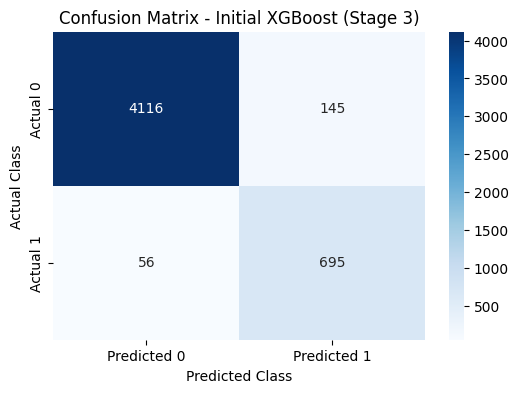

In [120]:
# --- Cell S3.12: XGBoost Model (Stage 3) - Instantiation, Training, and Evaluation ---
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt # Ensure plt is imported if not already
import seaborn as sns # Ensure seaborn is imported if not already
import numpy as np # Ensure numpy is imported for value_counts

if 'X_train_s3' in locals() and 'y_train_s3' in locals() and 'X_test_s3' in locals() and 'y_test_s3' in locals():
    print("--- XGBoost Model Training and Initial Evaluation (Stage 3) ---")

    # Calculate scale_pos_weight for Stage 3 training data
    count_negative_class_s3 = y_train_s3.value_counts()[0] # Assuming 0 is the negative class
    count_positive_class_s3 = y_train_s3.value_counts()[1] # Assuming 1 is the positive class

    if count_positive_class_s3 > 0:
        scale_pos_weight_value_s3 = count_negative_class_s3 / count_positive_class_s3
        print(f"Calculated scale_pos_weight for Stage 3: {scale_pos_weight_value_s3:.2f}")
    else:
        scale_pos_weight_value_s3 = 1
        print("Warning: Positive class count is zero in y_train_s3. Using default scale_pos_weight=1.")

    # 1. Instantiate the XGBoost model
    xgb_model_s3 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        scale_pos_weight=scale_pos_weight_value_s3
    )
    print("\nXGBoost model (Stage 3) instantiated.")

    # 2. Fit the model on the Stage 3 training dataset
    print("Fitting the XGBoost model to the Stage 3 training data...")
    xgb_model_s3.fit(X_train_s3, y_train_s3)
    print("Model fitting complete.")

    # 3. Make predictions on the Stage 3 test set
    print("\nMaking predictions on the Stage 3 test set...")
    y_pred_xgb_s3 = xgb_model_s3.predict(X_test_s3)
    y_pred_proba_xgb_s3 = xgb_model_s3.predict_proba(X_test_s3)[:, 1]
    print("Predictions made.")

    # 4. Evaluate the model
    print("\n--- Model Performance on Stage 3 Test Set (Initial XGBoost) ---")

    accuracy_xgb_s3 = accuracy_score(y_test_s3, y_pred_xgb_s3)
    print(f"Accuracy: {accuracy_xgb_s3:.4f}")

    precision_xgb_s3 = precision_score(y_test_s3, y_pred_xgb_s3)
    print(f"Precision (for class 1 - Dropout): {precision_xgb_s3:.4f}")

    recall_xgb_s3 = recall_score(y_test_s3, y_pred_xgb_s3)
    print(f"Recall (for class 1 - Dropout): {recall_xgb_s3:.4f}")

    roc_auc_xgb_s3 = roc_auc_score(y_test_s3, y_pred_proba_xgb_s3)
    print(f"ROC AUC Score: {roc_auc_xgb_s3:.4f}")

    print("\nClassification Report (Stage 3 - Initial XGBoost):")
    print(classification_report(y_test_s3, y_pred_xgb_s3, target_names=['Class 0 (Completed)', 'Class 1 (Dropout)']))

    print("\nConfusion Matrix (Stage 3 - Initial XGBoost):")
    cm_xgb_s3 = confusion_matrix(y_test_s3, y_pred_xgb_s3)
    print(cm_xgb_s3)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_xgb_s3, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix - Initial XGBoost (Stage 3)')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

else:
    print("ERROR: Stage 3 training/testing data not found. Please ensure Cell S3.11 ran correctly.")

# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
